# Rectified Image Processing for Thermal Landscapes Project
### Nkuhlu
 PB 6/23/22 edited by EH 6/23/2026
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

##### Weird Things about Nkuhlu
- The shapefile has 3 columns for treatments: 
    - "Exclosure" which is either "Full"/"Partial"/"Open"
    - "TopoPositi" which is either "Upland"/"Lowland"
    - "Treatment" which is either "Inside"/"Outside"
    
### EDITED 8/9/22 To Only Include the Full and Open Exclosure.

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import seaborn as sns

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# # # Define inputs

mast_path = '/n/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes'
img_dir = Path('/n/davies_lab/Lab/data/Remote_sensing_data/Products_remote_sensing_data/Africa/South Africa/Kruger/Exclosures/NkuluEP/raster/rectifiedimages/thermal')
shp_f = Path(f"{mast_path}/data/in/Polygons_AD_current/Nkuhlu_polygon.shp")


# Set site/project string for output figures and stats
projstr = 'Nkuhlu'

# Set figure directory for output figures
figdir = Path(f'{mast_path}/out/figs/test/{projstr}/')
if not figdir.exists():
    figdir.mkdir()

# Set threshold of overlap tolerance btwn images
threshold = 0.25

# Set merged product dir for the project
# used for opening up CHM and other lidar data files
mergedprodstr = '2020-01-16_NkuluEP'

# # # END USER INPUTS

In [13]:
# # # Open up corresponding Lidar data file 

# Products - CHM, DTM
mpdir = Path(f'/n/davies_lab/Lab/data/Remote_sensing_data/Products_merged_remote_sensing_data/{mergedprodstr}/')

chmf = [t for t in mpdir.glob('./CHM/*025m*.tif')][0]

CHM = rioxr.open_rasterio(chmf,
                          parse_coordinates=True,
                          masked=True)

dtmf = [t for t in mpdir.glob('./DTM/*025m*.tif')][0]

DTM = rioxr.open_rasterio(dtmf,
                          parse_coordinates=True,
                          masked=True)

CHM.rio.write_crs("epsg:32736", inplace=True)
DTM.rio.write_crs("epsg:32736", inplace=True)

# Also, get PAI and Canopy Density Values from a diff folder
# Note, there's one folder per exclosure, 
# with multiple netcdf (.nc) and geotif files in there
# folders are named by TreatmentTopo (ex: "FullLowland")
# NOTE - That naming is unique to Nkhulu - 
# for other sites, PAI and Cover voxel metrics had to be made on a per image basis,
# not like Nkhulu, where there is a PAI map for each exclosure.
# Note that they are netcdf files, so you need to call the variable when you open it
# https://rasterio.readthedocs.io/en/latest/topics/datasets.html
gridmetricdir = Path('/n/davies_lab/Lab/data/LabLidarScripts/data/out/test/nkhulu/grid_metrics')

# # #

# Load shapefile
shp = gpd.read_file(shp_f)

# Reproject Shapefile to 32736 (if it's not already)
shp = shp.to_crs('EPSG:32736')

# FILTER SHAPEFILE for only Full and Open - 8/9/22
shp = shp.loc[((shp.Exclosure == 'Full') | (shp.Exclosure == 'Open'))]

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Set hue order for plotting
exclosure_hues=["Outside", "Inside"]
topo_hues = ["Upland", "Lowland"]

# NOTE: The below is discontinued as of 6/22/2022 -
# instead the code goes through all images that overlap multiple treatments
# And removes images based on the above overlap threshold
# Set number of images to consider for final image list 
# nimgs = 1000

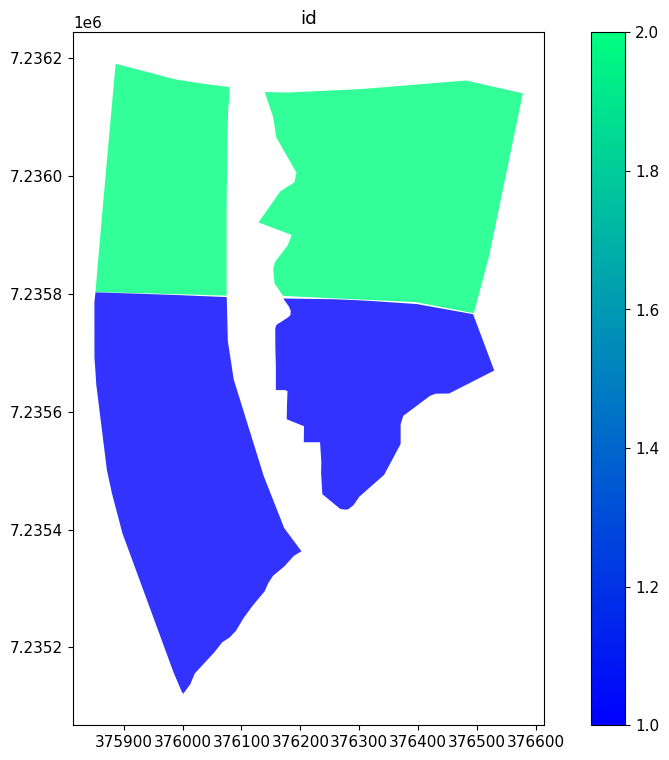

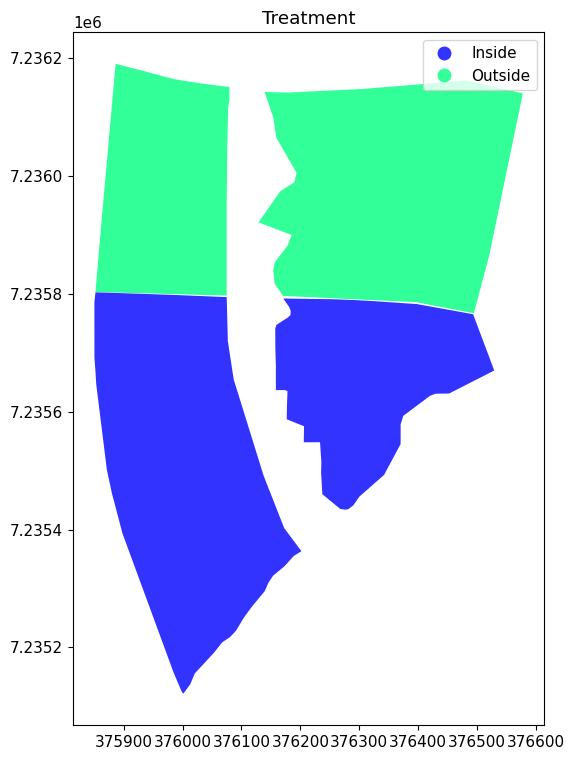

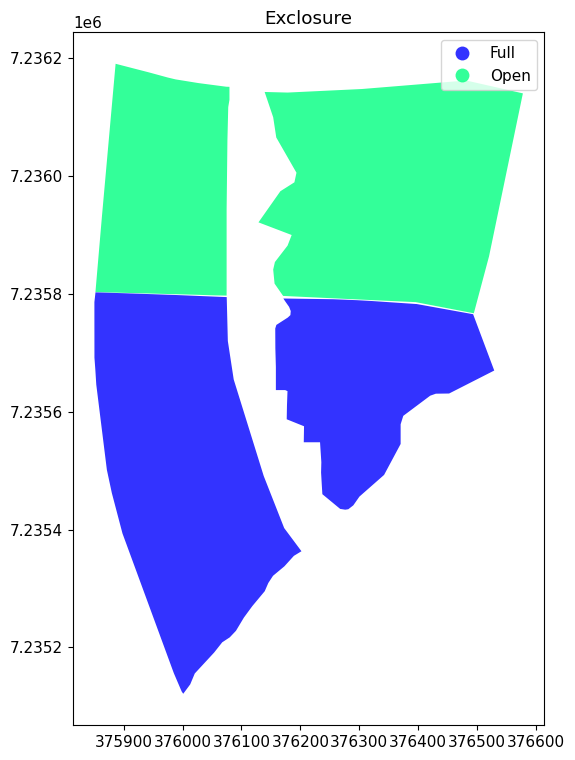

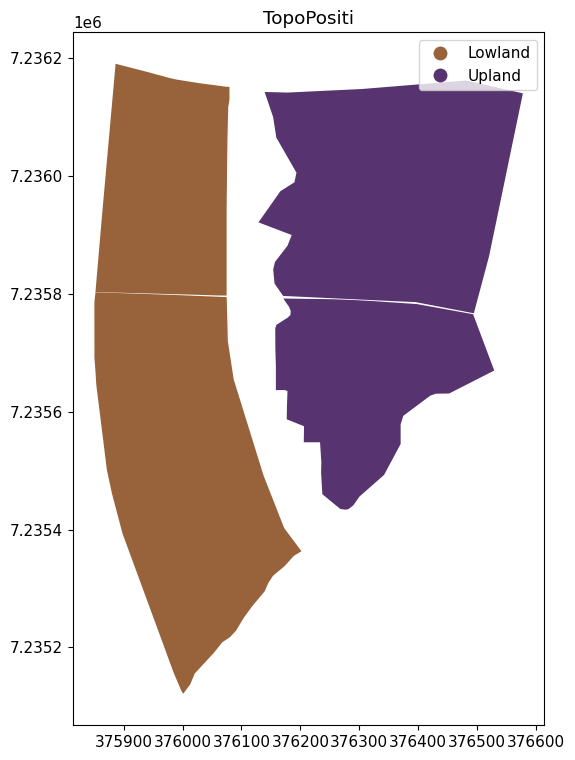

In [14]:
# Plot shapefile attributes
for c in shp.columns[0:-1]:
    if c == 'TopoPositi':
        shp.plot(column=c, legend=True, cmap='PuOr', alpha=0.8)
    else:
        shp.plot(column=c, legend=True, cmap='winter', alpha=0.8)
    plt.title(c)
    plt.savefig(f'{figdir}/ShapefileFeatures_{c}_{projstr}.jpg', dpi=300)

In [15]:
# Define a simple evenness function
# compares the difference in coverage between images
def evenness(x):
    # Filter for non-zero values
    X = x.loc[x>=0.01]
    # if more than 2:
    if len(X)>=2:
        
        # Calc coeff. of variation and multiply by 
         # -1 so scale is descending
        even = -1*(np.std(X)/np.mean(X))
        
    else:
        even = np.nan
    return even

def classifyVegType(h):
    
    h = np.round(h, 5)
    
    # "bare ground" pixels
    if ((h > -0.03) & (h <= 0.05)):
        veg = 'ground'
        
    # grass
    elif ((h > 0.05) & (h <= 0.5)):
        veg = 'grass'
        
    # shrub
    elif ((h > 0.5) & (h <= 3)):
        veg = 'shrub'
        
    # tree (just using the top bracket to filter out noise points)
    elif ((h > 3) & (h <= 20)):
        veg = 'tree'
        
    else:
        veg = np.nan
        
    return veg
        

### Step 1: Filter imglist to maximize overlap with polygon treatments

In [16]:
# Make list of images to loop through
img_list = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# img_list = img_list[0:100]

# Initialize list of img geometries
geom_list = []

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # warnings.filterwarnings(action='once')
    
    # Loop through each image
    for f in img_list:

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        # Make Boundary in to a Shapely Polygon, and save in a list
        geom_list.append(Polygon(zip(x_list, y_list)))

    # Make a Geodataframe from the result
    img_gdf = gpd.GeoDataFrame({'img':img_list, 'geometry':geom_list}, geometry='geometry', crs='EPSG:32736')

    # Use the shapefile to get the area overlap of each of the images and each of the treatments
    for ID, T, feat in zip(shp.index, shp.Treatment, shp.geometry.values):
        
        temp = img_gdf.geometry.apply(feat.intersection)

        # Save absolute area of overlap (not as useful as the percent overlap)
        img_gdf[f'Area {T} {ID}'] = temp.area

        # Save percent overlap with feature
        img_gdf[f'Overlap {T} {ID}'] = temp.area / feat.area
        
        warnings.filterwarnings(action='once')

    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Sum'] = img_gdf.filter(like='Overlap').apply(np.nansum, axis=1)
    
    # Filter for area coverage
    # Note: If you do this with percent coverages, as oppossed to absolute area
    # you get images that overlap 
    # Compute the sum overlapping area percentages
    img_gdf['Evenness'] = img_gdf.filter(like='Overlap').apply(lambda x: evenness(x), axis=1)

    # Sort and redindex values in descending order of evenness, then summed percent overlap
    img_gdf.sort_values(by=['Evenness','Sum'], axis=0, inplace=True, ascending=False, ignore_index=True)
    

img_gdf rows: 2935
img_gdf_filter rows: 159

shp rows: 4
Exclosure values:
Exclosure
Open    2
Full    2
Name: count, dtype: int64

TopoPositi values:
TopoPositi
Lowland    2
Upland     2
Name: count, dtype: int64

Constructed grid-metric names from shapefile:
['FullLowland', 'FullUpland', 'OpenLowland', 'OpenUpland']

Available grid metric folders:
['FullLowland', 'FullUpland', 'OpenLowland', 'OpenUpland']


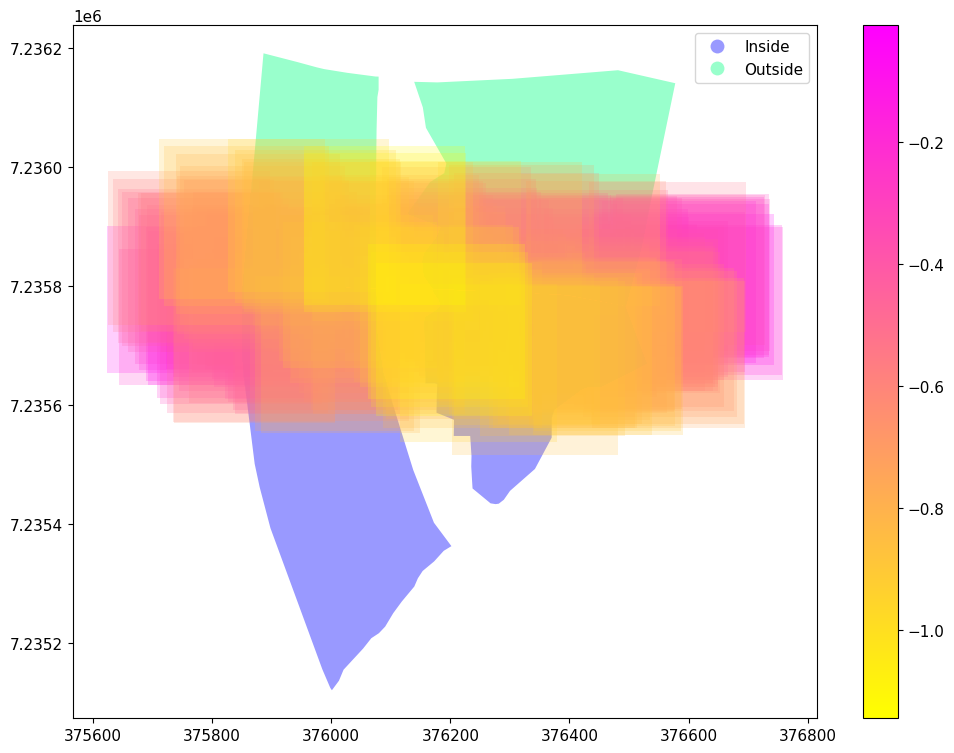

In [17]:
# Keep only the images that overlap multiple treatments
# Cutoff is that img has to overlap at least 100 m2 
# img_gdf['OverlapsTreatments'] = img_gdf.filter(like='Area').apply(lambda x: np.sum(x>100) > 1, axis=1)
# img_gdf_filter = img_gdf.loc[img_gdf['OverlapsTreatments']]

# Keep only the images that overlap multiple treatments
# (Cutoff is that img has to overlap at least 1000 m2)
# Note: This cutoff can be tuned to each site.
# In some cases, you may want less images. In others, more.
# Edited 7/5/2022 to only count images that overlap both inside and outside,
# Discluding images that overlap 2 polygons, but both polygons are labelled as the same treatment.
areathres = 2000
img_gdf['OverlapsInside'] = img_gdf.filter(like='Area Inside').apply(lambda x: np.sum(x>areathres) > 0, axis=1)
img_gdf['OverlapsOutside'] = img_gdf.filter(like='Area Outside').apply(lambda x: np.sum(x>areathres) > 0, axis=1)
img_gdf_filter = img_gdf.loc[img_gdf['OverlapsInside'] & img_gdf['OverlapsOutside']]


# SPECIFIC TO NKULU
# added another filter here for pesky images that won't go
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-000-000157-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000065-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000066-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000067-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000068-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000069-0.tif')]
img_gdf_filter = img_gdf_filter.loc[img_gdf_filter.img!=Path('/n/davies_lab/Lab/data/products/2020_01-02/NkuluEP/raster/rectifiedimages/thermal/Flight2_cam1-004-000070-0.tif')]


fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, column='Treatment',
         legend=True, cmap='winter',
         alpha=0.4)
img_gdf_filter.plot(ax=ax, alpha=0.2, cmap='spring_r', column='Evenness', legend=True)

plt.savefig(f'{figdir}/ImageSelection_AllImagesbyEvenness_{projstr}.jpg', dpi=300)

print("img_gdf rows:", len(img_gdf))
print("img_gdf_filter rows:", len(img_gdf_filter))

print("\nshp rows:", len(shp))
print("Exclosure values:")
print(shp["Exclosure"].value_counts(dropna=False))
print("\nTopoPositi values:")
print(shp["TopoPositi"].value_counts(dropna=False))

print("\nConstructed grid-metric names from shapefile:")
print(sorted(set(shp["Exclosure"].astype(str) + shp["TopoPositi"].astype(str))))

print("\nAvailable grid metric folders:")
print(sorted([p.name for p in Path(gridmetricdir).iterdir() if p.is_dir()]))


### Step 2 - Choose a random set of images that do not overlap with each other

In [18]:
# Output dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':{}.fromkeys(shp.index, []), 
              'pixels_xr':{}.fromkeys(shp.index, []),
              'x_xr':{}.fromkeys(shp.index, []),
              'y_xr':{}.fromkeys(shp.index, []),
              'z_xr':{}.fromkeys(shp.index, []),
              'h_xr':{}.fromkeys(shp.index, []),
              'cd_xr':{}.fromkeys(shp.index, []),
              'pai_xr':{}.fromkeys(shp.index, []),
              'Exclosure':{}.fromkeys(shp.index, []),
              'Polygon':{}.fromkeys(shp.index, []),
              'Topo':{}.fromkeys(shp.index, [])}

# Edited 7/5/2022 - don't need pixels_xr in img_dict, since it's in pixel_dict
img_dict = {'imgf':[], 'boundary_poly':[]}

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, g in zip(img_gdf_filter.img.values,
                    img_gdf_filter.geometry.values):

        # Load image
        img = rioxr.open_rasterio(i,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Make a geodataframe to use below
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[g])

        # Check the image's overlap with all previous images that have been processed thusfar
        poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(g)

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(g)
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/g.area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):
            
            img_dict['imgf'].append(str(i).split('/')[-1])
            
            # Save the shapely polygon
            img_dict['boundary_poly'].append(g)

            # loop through features in shapefile
            for ID, feat in zip(shp.index, shp.geometry.values):
                
                # Open netcdf file associated with this treatment
                name = f'{shp.loc[ID].Exclosure}{shp.loc[ID].TopoPositi}'
                coverd2f = f'{gridmetricdir}/{name}/{name}_CoverD2.nc'
                PAId2f = f'{gridmetricdir}/{name}/{name}_FHPD2.nc'

                # Open canopy density for this exclosure
                CD = rioxr.open_rasterio(coverd2f,
                                          parse_coordinates=True,
                                          masked=True)
                
                # Subset to Canopy Density at 5 cm
                CD = CD[CD.z==0.05]
                
                # Open PAI
                PAI = rioxr.open_rasterio(PAId2f,
                                          parse_coordinates=True,
                                          masked=True)
                

                # Only get PAI above 0.05 m
                PAI = PAI[PAI.z>0.05]
                
                # Sum to get total
                PAI_sum = PAI.sum(dim='z')
                
                # Save to raster for qgis
                PAI_sum.rio.to_raster(f'{mast_path}/out/raster/{name}_PAIabove5cm.tif')
                
                # Save attributes from images and shapefiles in nested dict
                pixel_dict['imgf'][ID].append(str(i).split('/')[-1])
                pixel_dict['Exclosure'][ID].append(shp.loc[ID].Treatment)
                pixel_dict['Topo'][ID].append(shp.loc[ID].TopoPositi)
                pixel_dict['Polygon'][ID].append(feat)

                # Get the intersection, and clip your raster with it
                if clipbox.intersects(feat)[0]:
                    
                    pixels = img_k.rio.clip(clipbox.intersection(feat), drop=True)     

                    # # # Save lidar data in dict as well for later comparison
                    
                    # Use rio.reproject_match to cut out relevant area of the CHM, DTM, and CD
                    # and resample onto the same grid with same spatial res (0.5 m)
                    CHM_match = CHM.rio.reproject_match(pixels)
                    DTM_match = DTM.rio.reproject_match(pixels)
                    CD_match = CD.rio.reproject_match(pixels)
                    PAI_match = PAI_sum.rio.reproject_match(pixels)
                    
                    
                    # Also, get the x,y coordinates of the pixels 
                    # (enables nearest tree analysis, etc., later)
                    yy, xx = np.meshgrid(pixels.y.values, pixels.x.values, indexing="ij")
                    x = xr.DataArray(xx, dims=["y", "x"], coords={"x": pixels.x, "y": pixels.y})
                    y = xr.DataArray(yy, dims=["y", "x"], coords={"x": pixels.x, "y": pixels.y})
                    
                    # Last, get the Clidar metric values for all the pixels
                    h = CHM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    z = DTM_match.rio.clip(clipbox.intersection(feat), drop=True)
                    cd = CD_match.rio.clip(clipbox.intersection(feat), drop=True)
                    pai = PAI_match.rio.clip(clipbox.intersection(feat), drop=True)
                    
                else:
                    
                    pixels=[]
                    x=[]
                    y=[]
                    z=[]
                    h=[]
                    pai=[]
                    cd=[]
                    n=0
                    
                # Store all pixels in the nested dictionary
                pixel_dict['pixels_xr'][ID].append(pixels)
                pixel_dict['x_xr'][ID].append(x)
                pixel_dict['y_xr'][ID].append(y)
                pixel_dict['z_xr'][ID].append(z)
                pixel_dict['h_xr'][ID].append(h)
                pixel_dict['cd_xr'][ID].append(cd)
                pixel_dict['pai_xr'][ID].append(pai)


for ID in pixel_dict["pixels_xr"]:
    vals = pixel_dict["pixels_xr"][ID]
    non_empty = [v for v in vals if hasattr(v, "size") and v.size > 0]
    print(ID, "total:", len(vals), "non-empty:", len(non_empty))

print("\nImages stored by ID:")
for ID in pixel_dict["imgf"]:
    print(ID, len(pixel_dict["imgf"][ID]), pixel_dict["imgf"][ID][:5])
                

0 total: 20 non-empty: 10
1 total: 20 non-empty: 10
3 total: 20 non-empty: 10
4 total: 20 non-empty: 10

Images stored by ID:
0 20 ['Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-002-000147-0.tif']
1 20 ['Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-002-000147-0.tif']
3 20 ['Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-002-000147-0.tif']
4 20 ['Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-000-000201-0.tif', 'Flight2_cam1-002-000147-0.tif']


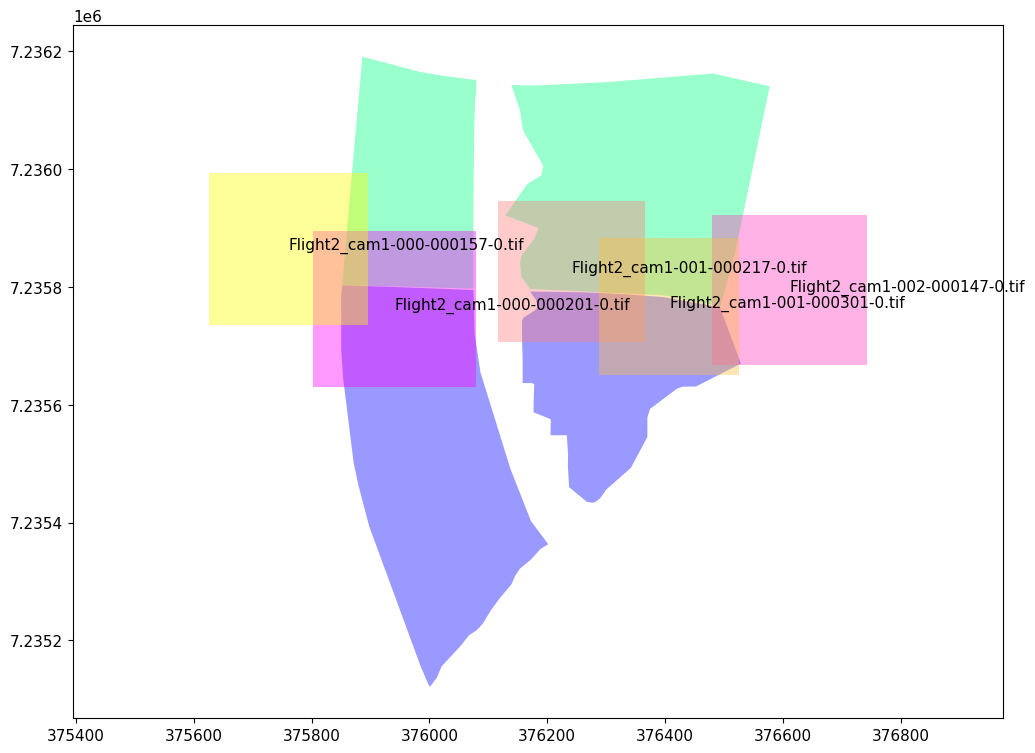

In [19]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=img_dict['boundary_poly'], crs='EPSG:32736')

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4, column='Treatment')
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s) for s in np.array(img_dict['imgf'])]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)
    
fig.savefig(f'{figdir}/FinalImageOverlap_{projstr}.png', dpi=300)

In [20]:
#something is up with cell building, check everything
for ID in pixel_dict["pixels_xr"]:
    for j, pix in enumerate(pixel_dict["pixels_xr"][ID]):
        if hasattr(pix, "size") and pix.size > 0:
            print("First non-empty:")
            print("ID:", ID)
            print("j:", j)
            print("img:", pixel_dict["imgf"][ID][j])
            print("pixels shape:", pix.shape)
            print("pixels size:", pix.size)
            print("pixels dims:", pix.dims)
            print("pixels min/max:", float(pix.min()), float(pix.max()))

            h = pixel_dict["h_xr"][ID][j]
            cd = pixel_dict["cd_xr"][ID][j]
            pai = pixel_dict["pai_xr"][ID][j]

            print("height type:", type(h))
            print("height shape:", getattr(h, "shape", None))
            print("height min/max:", float(h.min()), float(h.max()))

            print("cd shape:", getattr(cd, "shape", None))
            print("pai shape:", getattr(pai, "shape", None))
            raise SystemExit

First non-empty:
ID: 0
j: 0
img: Flight2_cam1-000-000201-0.tif
pixels shape: (326, 743)
pixels size: 242218
pixels dims: ('y', 'x')
pixels min/max: 305.7200012207031 319.3599853515625
height type: <class 'xarray.core.dataarray.DataArray'>
height shape: (1, 326, 743)
height min/max: 0.0 11.911999702453613
cd shape: (1, 326, 743)
pai shape: (326, 743)


SystemExit: 

/n/holystore01/LABS/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes/.venv/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [21]:
# Unpack into Dataframe for plotting
# and for comparison with CHM and structure data

# Initialize df list for loop
df_list = []

# For each polygon treatment in the shapefile
for ID in shp.index:
    
    # For each image
    for i, img in enumerate(pixel_dict['imgf'][ID]):
        
        df = pd.DataFrame()
        
        # If there are pixels for this treatment (it's NOT an empty list)
        if len(pixel_dict['pixels_xr'][ID][i])!=0:
            
            # Make an exploded dataframe, with each pixel noted by it's treatment, topo, and imgfile
            df = pd.DataFrame({'Temperature':pixel_dict['pixels_xr'][ID][i].data.flatten() - 273.15,
                               'Height':pixel_dict['h_xr'][ID][i].data.flatten(),                         
                               'Elevation':pixel_dict['z_xr'][ID][i].data.flatten(),
                               'CanopyDensity':pixel_dict['cd_xr'][ID][i].data.flatten(),
                               'PAI':pixel_dict['pai_xr'][ID][i].data.flatten(),
                               'Exclosure':pixel_dict['Exclosure'][ID][i],
                               'Topo':pixel_dict['Topo'][ID][i],
                               'imgf':img})
            

            # Drop na rows
            df.dropna(axis=0, how='any', inplace=True)
            
            # store DataFrame in list
            df_list.append(df.copy(deep=True))

# Concat all the dfs to make a full df 
df_pixels = pd.concat(df_list, ignore_index=True, sort=False)


print("df_pixels shape:", df_pixels.shape)

print("\nExclosure counts:")
print(df_pixels["Exclosure"].value_counts(dropna=False))

print("\nTemperature:")
print(df_pixels["Temperature"].describe())

print("\nHeight:")
print(df_pixels["Height"].describe())

print("\nRows usable for plots:")
print(df_pixels[["Exclosure", "Temperature", "Height"]].dropna().shape)

df_pixels shape: (4864632, 8)

Exclosure counts:
Exclosure
Inside     2595060
Outside    2269572
Name: count, dtype: int64

Temperature:
count    4.864632e+06
mean     3.813670e+01
std      2.675869e+00
min      3.257001e+01
25%      3.592999e+01
50%      3.764999e+01
75%      3.988998e+01
max      6.132999e+01
Name: Temperature, dtype: float64

Height:
count    4.864632e+06
mean     1.743614e+00
std      2.284728e+00
min      0.000000e+00
25%      1.290000e-01
50%      9.360000e-01
75%      2.515000e+00
max      1.716800e+01
Name: Height, dtype: float64

Rows usable for plots:
(4864632, 3)


In [22]:
# Add Vegtype, and save outputs as pickles

# # using list comprehension
vs = [classifyVegType(h) for h in df_pixels.Height]
df_pixels['VegType'] = vs

# Also, add canopy density as a percent
df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100

# Save output as pickle obj file
df_pixels.to_pickle(f'{mast_path}/out/pixelpickles/{projstr}_pixels.obj')

# And make a df for plotting above 10 cm height
df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

In [23]:
# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.35, style="ticks", rc=custom_params)

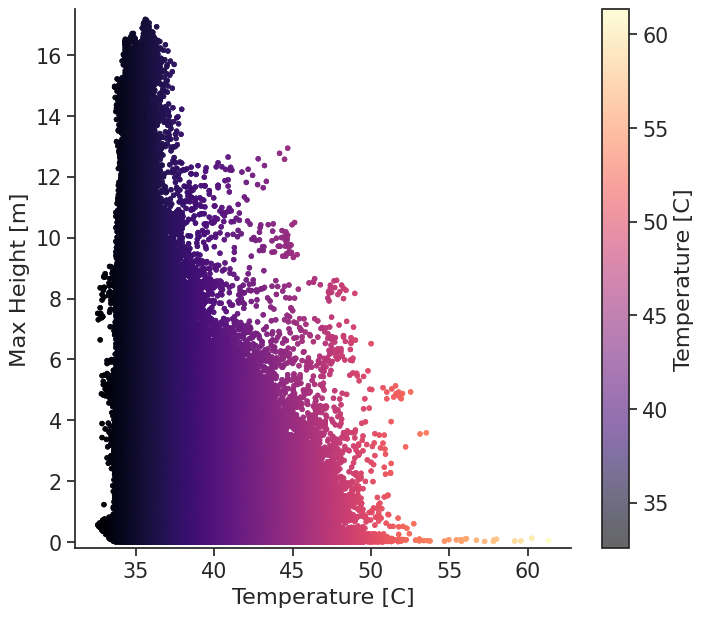

In [24]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

a = ax.scatter(x=df_pixels.Temperature,
               y=df_pixels.Height,
               c=df_pixels.Temperature,
               alpha=0.6, cmap='magma', s=15,
               marker='o', edgecolors='none')

# vmin=24, vmax=50

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Max Height [m]')

fig.savefig(f'{figdir}/ScatterPlot_TempxHeight_{projstr}.jpg', dpi=300)

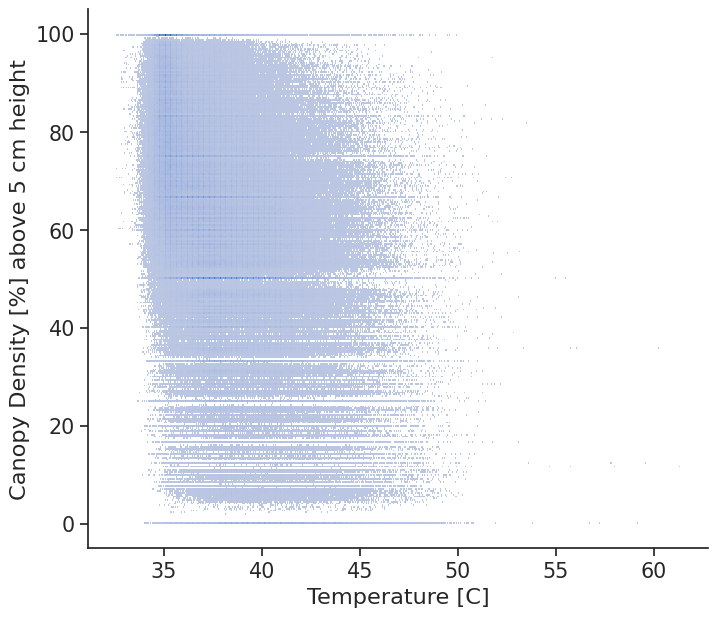

In [25]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='CanopyDensityPercent', ax=ax)

ax.set_ylim(-5, 105)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Canopy Density [%] above 5 cm height')

fig.savefig(f'{figdir}/HistPlot_TempxCanopyDensity_{projstr}.jpg', dpi=300)

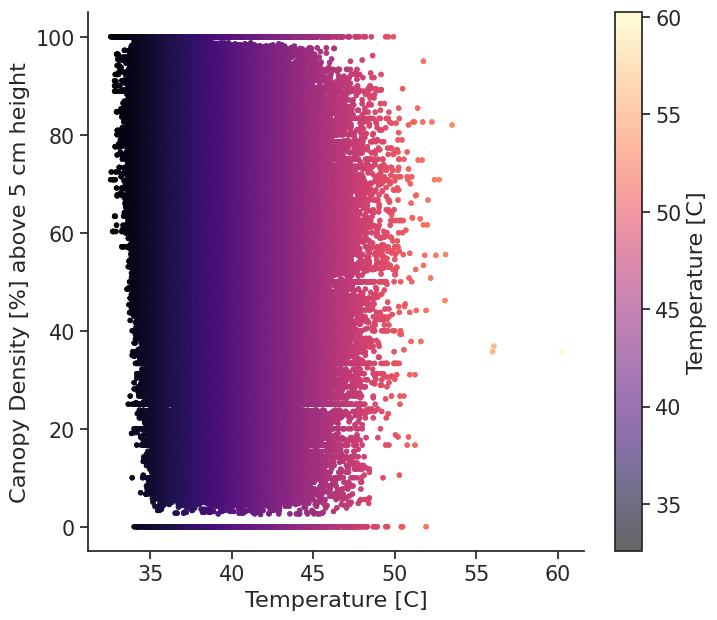

In [26]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.CanopyDensity*100,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, marker='o', edgecolors='none',
               
              )

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-5, 105)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Canopy Density [%] above 5 cm height')

fig.savefig(f'{figdir}/ScatterPlot_TempxCanopyDensity_{projstr}.jpg', dpi=300)

/n/holystore01/LABS/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes/.venv/lib/python3.8/site-packages/seaborn/axisgrid.py:241: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()
/n/holystore01/LABS/davies_lab/Lab/shared_projects/ThermalLandscapes/ThermalLandscapes/.venv/lib/python3.8/site-packages/seaborn/axisgrid.py:241: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  handles, labels = ax.get_legend_handles_labels()


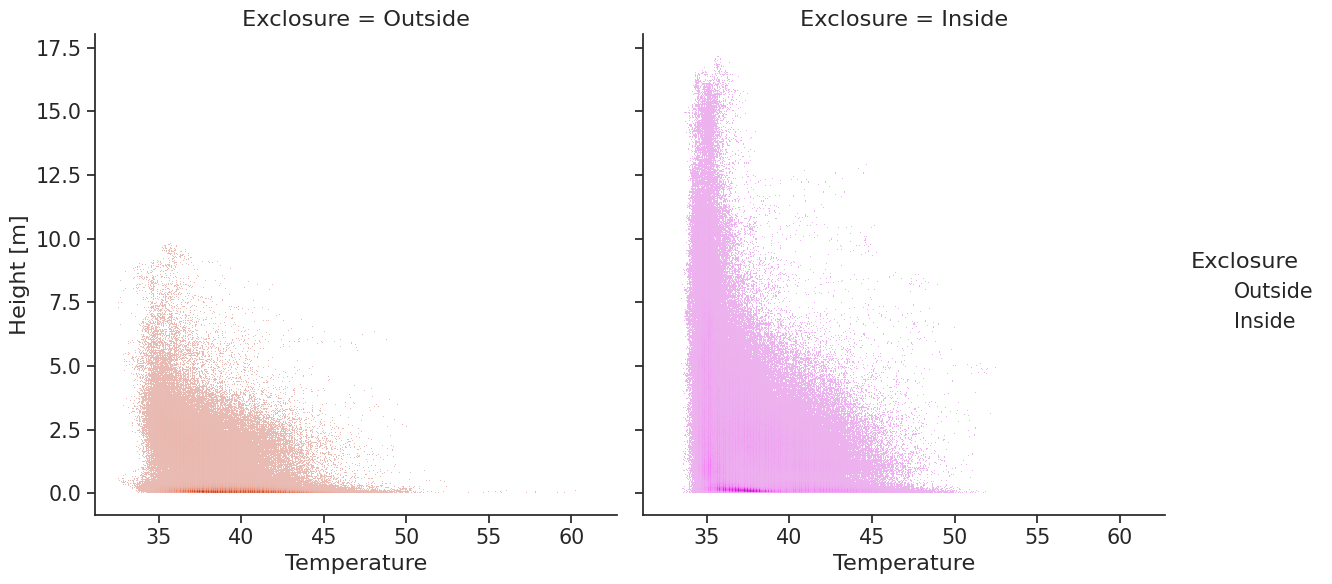

In [27]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [16, 14]
plt.rcParams.update({'font.size': 12})

# fig, ax = plt.subplots()

# sns.histplot(data=df_pixels, x=f'Temperature', y='Height', hue='Exset_xlim,
#              palette='plasma_r', hue_order=exclosure_hues, ax=ax)

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels, col='Exclosure', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues, height=6)

FG.map_dataframe(sns.histplot, x=f'Temperature', y='Height')

FG.set_xlabels(f'Temperature')
FG.set_ylabels('Height [m]')
    
FG.add_legend()
# FG.tight_layout()

FG.savefig(f'{figdir}/DisPlot_TempvHeight_Exclosure_{projstr}.jpg', dpi=300)

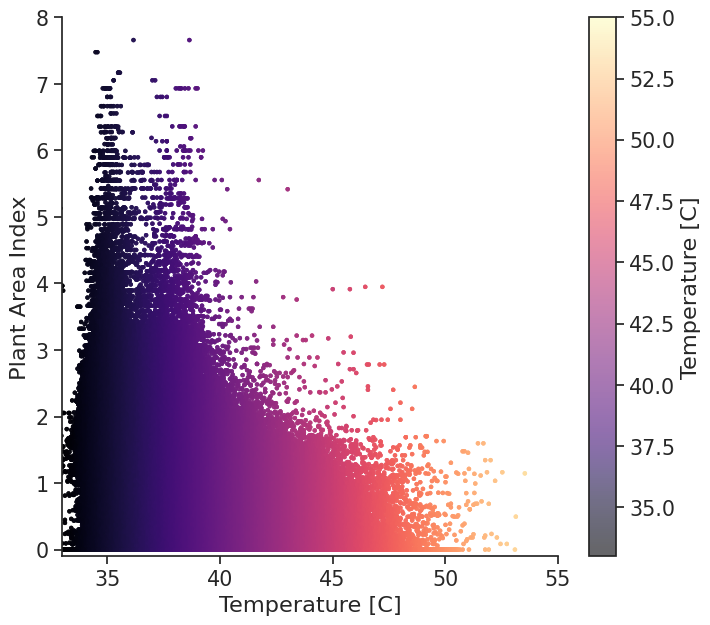

In [28]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

df_pixels_0p1m = df_pixels.loc[df_pixels.Height >= 0.1]

a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=10, marker='o',
               edgecolors='none',
               vmin=33,
               vmax=55)

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 8)

ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{projstr}.jpg', dpi=300)

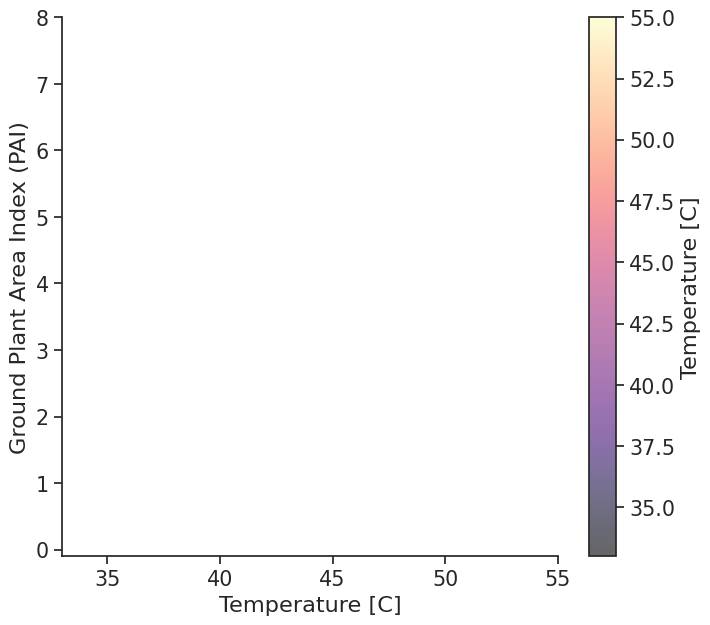

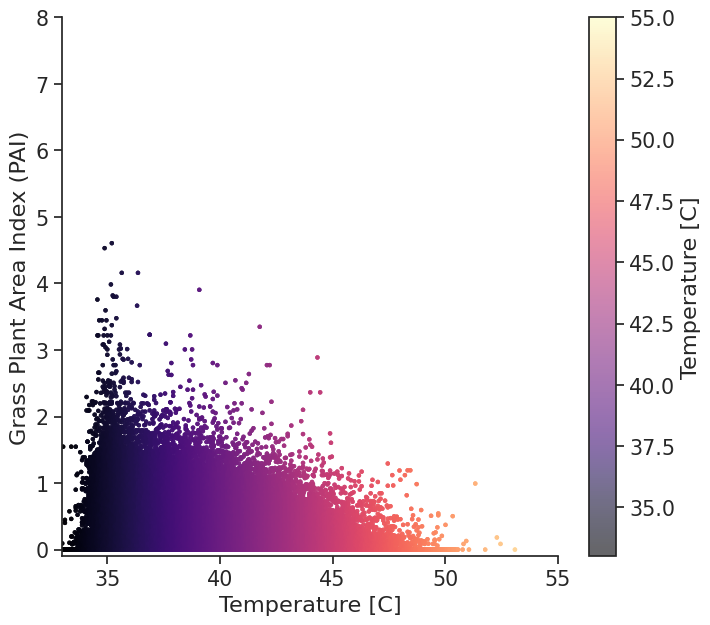

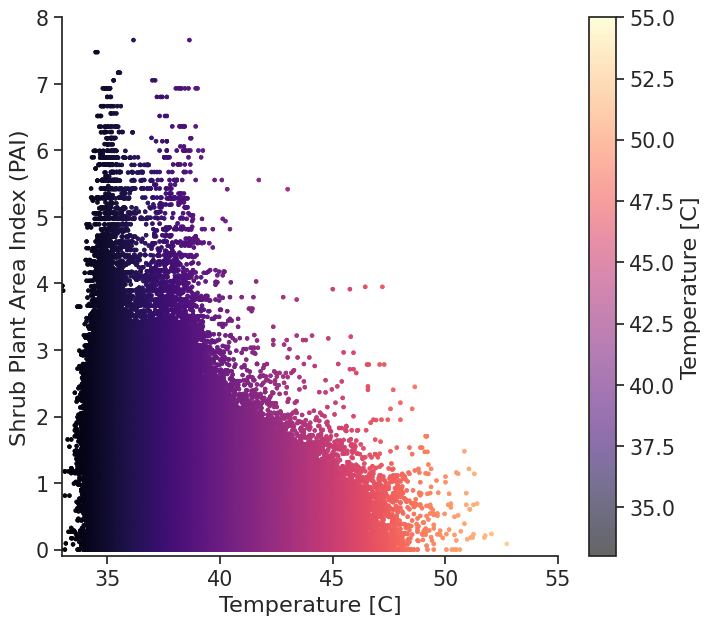

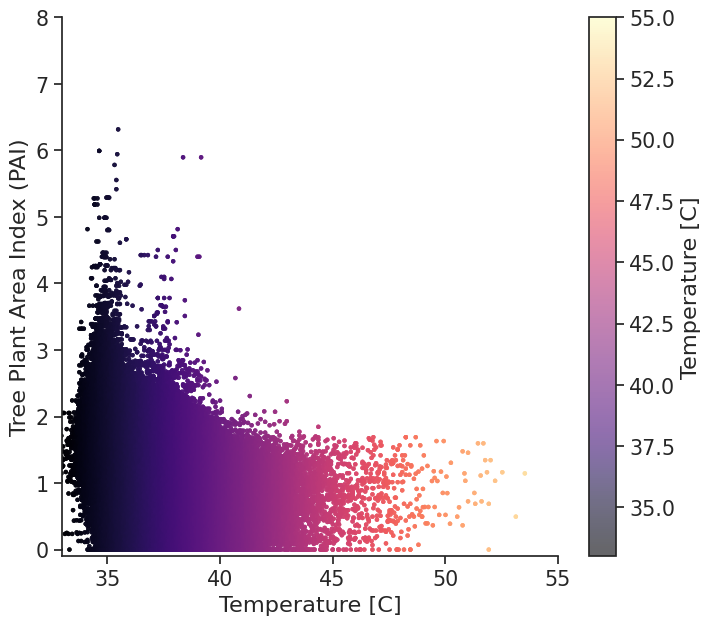

In [29]:
# Ground, grass, shrub, tree plots
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    df_veg = df_pixels_0p1m.loc[df_pixels_0p1m.VegType == ggst]
    
    a = ax.scatter(x=df_veg.Temperature,
                   y=df_veg.PAI,
                   c=df_veg.Temperature,
                   alpha=0.6,
                   cmap='magma',
                   s=10,
                   marker='o',
                   edgecolors='none',
                   vmin=33,
                   vmax=55)

    fig.colorbar(a, label='Temperature [C]')
    
    ax.set_ylim(-0.1, 8)

    ax.set_xlim(33, 55)
    ax.set_xlabel('Temperature [C]')
    ax.set_ylabel(f'{ggst.capitalize()} Plant Area Index (PAI)')
    
    fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_{ggst}_{projstr}.png', dpi=300)

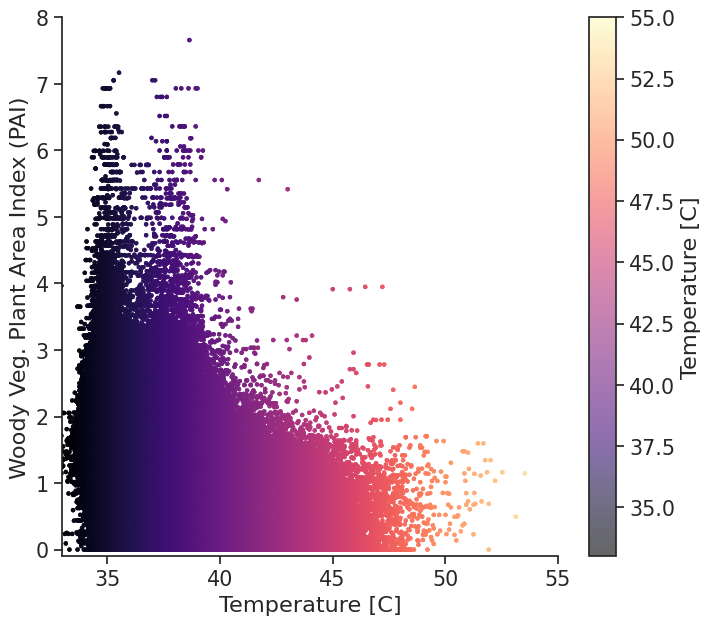

In [30]:
# also added a woody veg. plot
# woodyidx = (df_pixels.Height > 1)

fig, ax = plt.subplots()
    
df_veg = df_pixels_0p1m.loc[(df_pixels_0p1m.Height > 1)]

a = ax.scatter(x=df_veg.Temperature,
               y=df_veg.PAI,
               c=df_veg.Temperature,
               alpha=0.6,
               cmap='magma',
               s=10,
               marker='o',
               edgecolors='none',
               vmin=33,
               vmax=55)

fig.colorbar(a, label='Temperature [C]')

ax.set_ylim(-0.1, 8)
ax.set_xlim(33, 55)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel(f'Woody Veg. Plant Area Index (PAI)')

fig.savefig(f'{figdir}/ScatterPlot_TempxPAI_WoodyVeg_{projstr}.png', dpi=300)

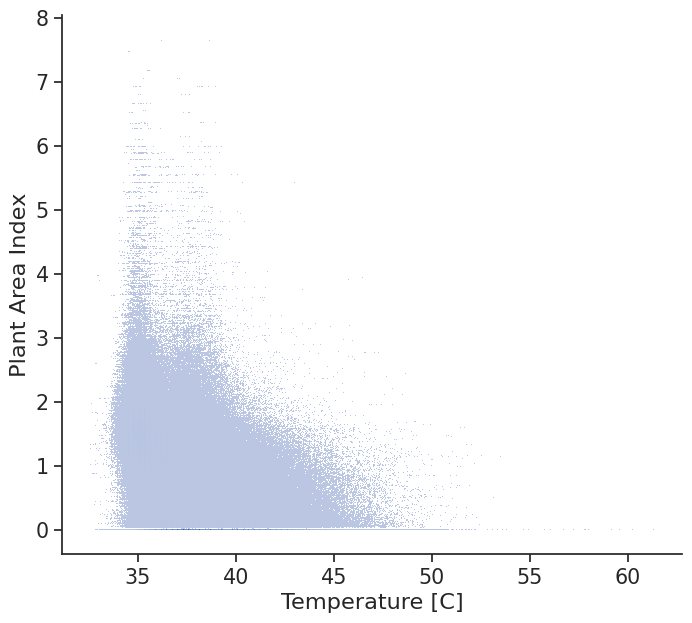

In [31]:
# df_pixels['CanopyDensityPercent'] = df_pixels.CanopyDensity*100
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='PAI', ax=ax)

# ax.set_ylim(-0.1, 1.5)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Plant Area Index')

fig.savefig(f'{figdir}/HistPlot_TempxPAI_{projstr}.jpg', dpi=300)

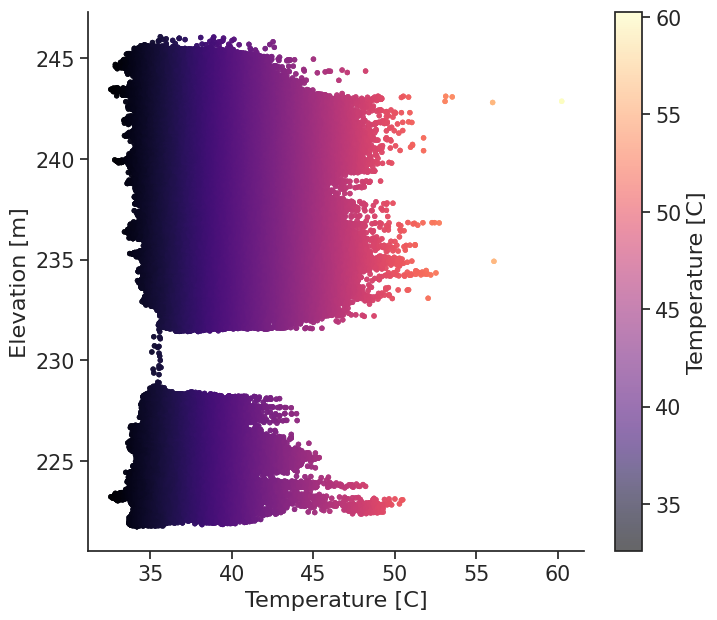

In [32]:
# # makes matplotlib plots big
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()


a = ax.scatter(x=df_pixels_0p1m.Temperature,
               y=df_pixels_0p1m.Elevation,
               c=df_pixels_0p1m.Temperature,
               alpha=0.6, cmap='magma', s=15, 
               marker='o', edgecolors='none',
              )
# vmin=24, vmax=50

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Elevation [m]')

fig.savefig(f'{figdir}/ScatterPlot_TempxElevation_{projstr}.jpg', dpi=300)

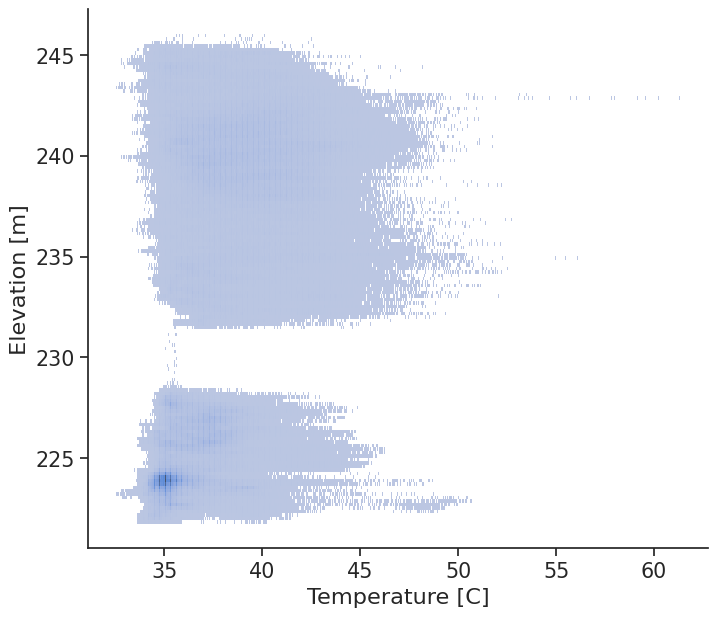

In [33]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.histplot(data=df_pixels, x=f'Temperature', y='Elevation', ax=ax)

# ax.set_ylim(-0.1, 1.5)
ax.set_xlabel('Temperature [C]')
ax.set_ylabel('Elevation [m]')

fig.savefig(f'{figdir}/HistPlot_TempxElevation_{projstr}.jpg', dpi=300)

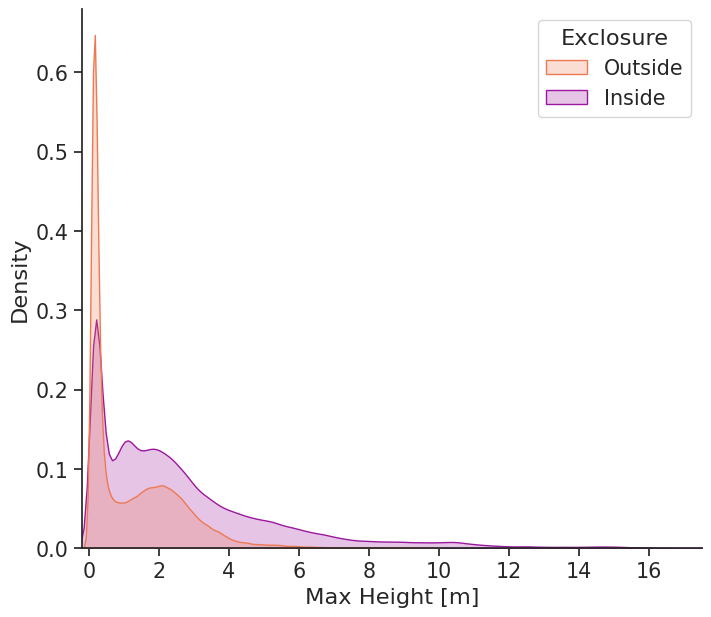

In [34]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='Height', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Max Height [m]')
ax.set_xlim(-0.2, 17.5)
fig.savefig(f'{figdir}/KDEplot_HeightbyExclosure_{projstr}.jpg', dpi=300)

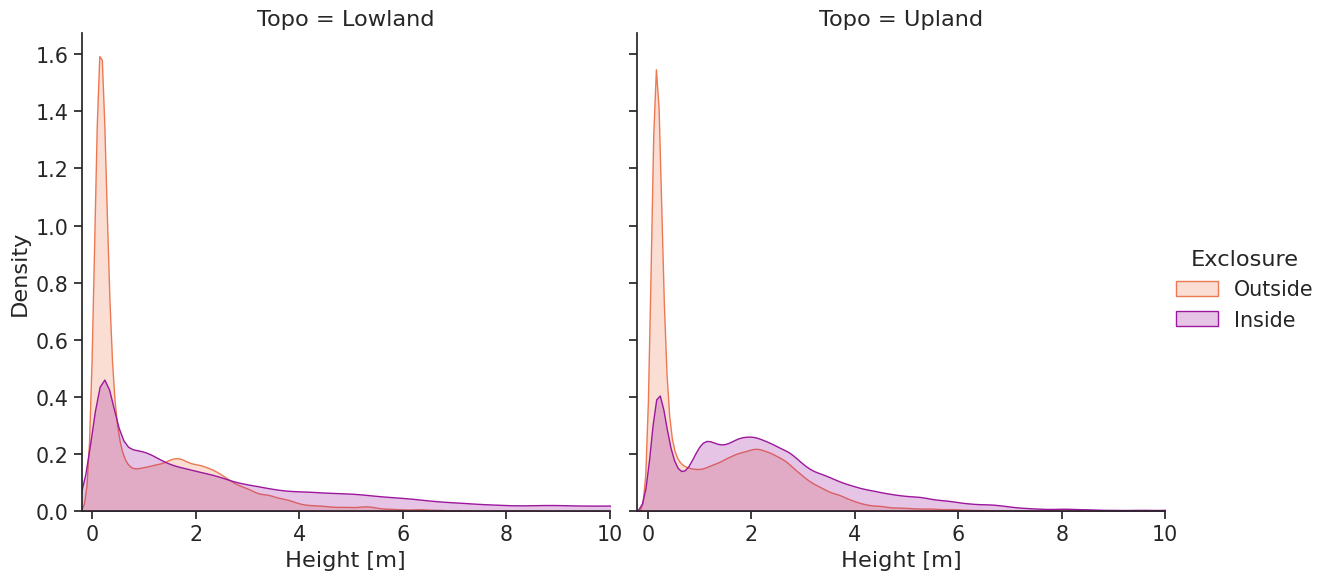

In [35]:
# Split by Lowland and Upland FacetGrid
# plt.rcParams['figure.figsize'] = [12, 6]
# plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues, height=6,
                   col_order=['Lowland', 'Upland'])

FG.map_dataframe(sns.kdeplot, x='Height', fill=True)

FG.set_xlabels(f'Height [m]')
    
FG.set_ylabels('Density')
FG.add_legend()
# FG.tight_layout()
FG.set(xlim=(-0.2, 10))

FG.savefig(f'{figdir}/KDEplot_HeightbyExclosureandTopo_{projstr}.jpg', dpi=300)

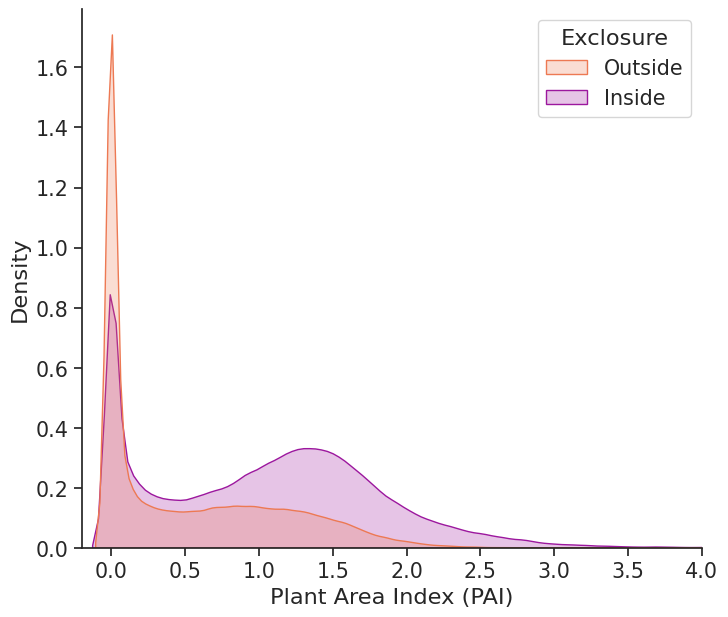

In [36]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='PAI', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Plant Area Index (PAI)')
ax.set_xlim(-0.2, 4)
fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_{projstr}.jpg', dpi=300)

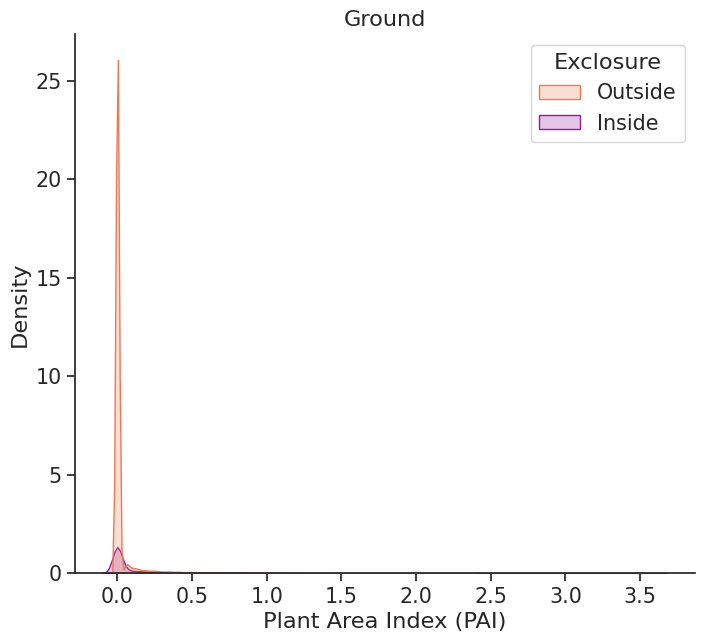

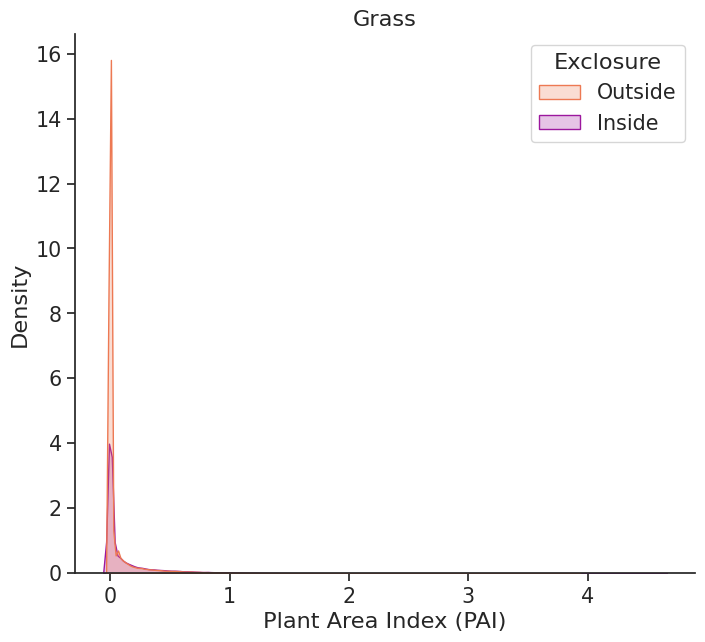

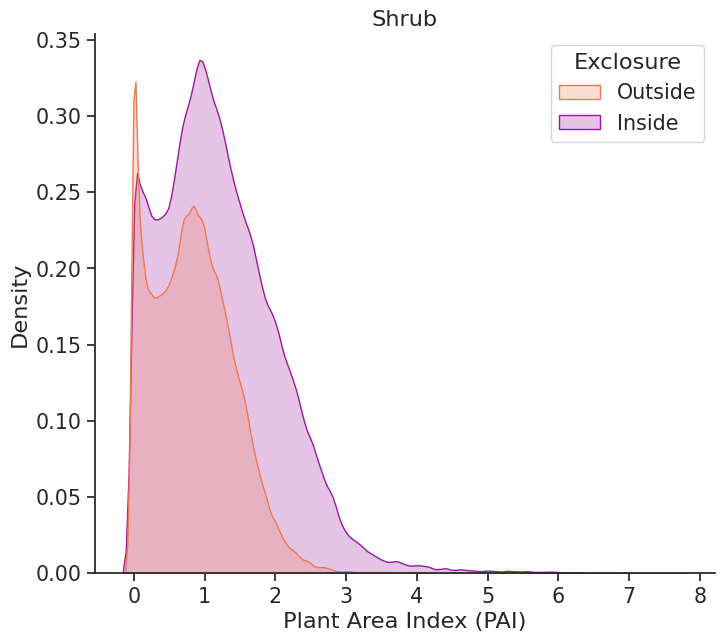

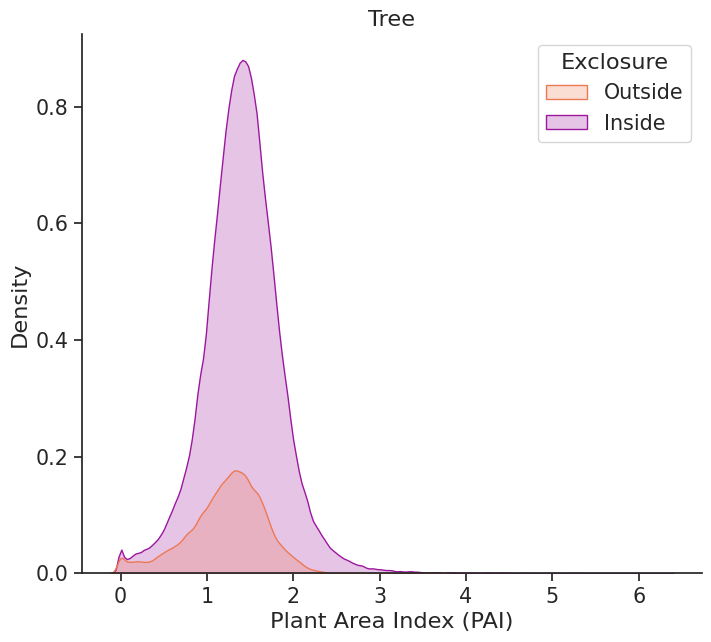

In [37]:
# Ground, grass, shrub, tree plots
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels.loc[df_pixels.VegType == ggst],
                x=f'PAI',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues)

    # ax.set_xlim(-0.2, 4)
    ax.set_xlabel('Plant Area Index (PAI)')
    ax.set_title(f'{ggst.capitalize()}')
    
    fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_{ggst}_{projstr}.jpg', dpi=300)

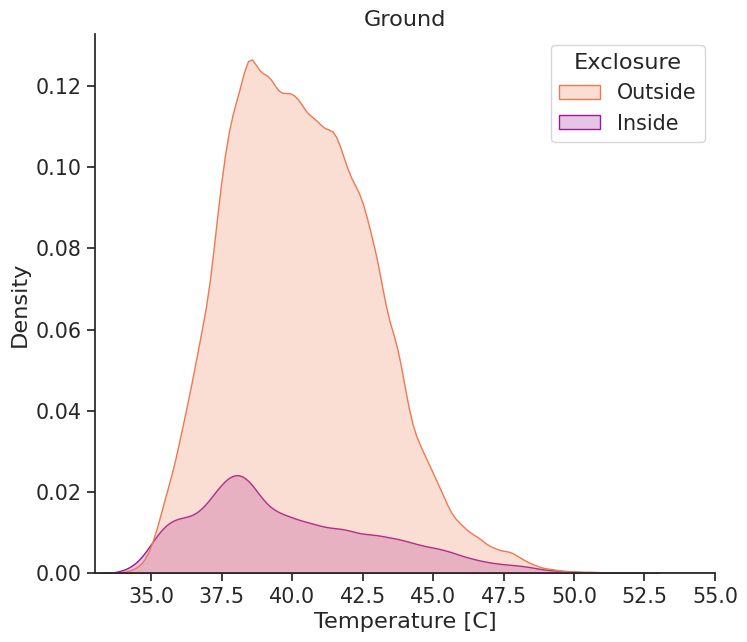

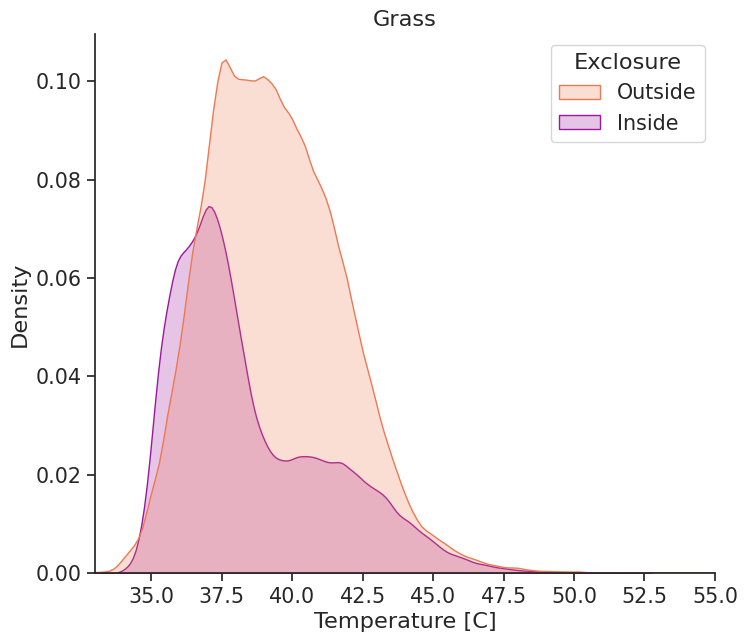

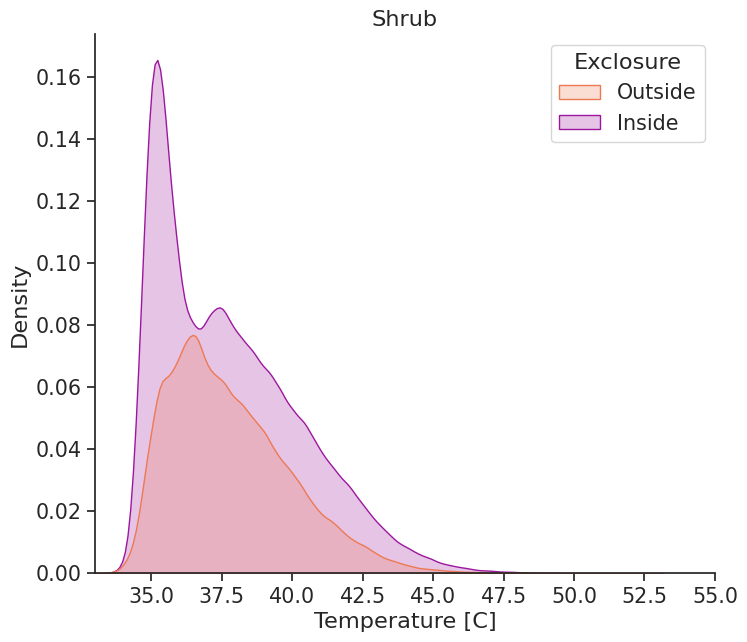

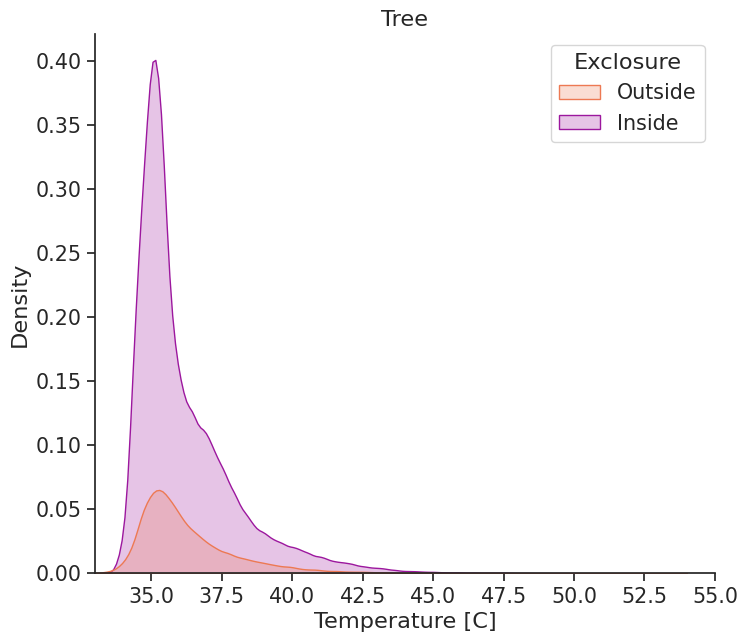

In [38]:
# Ground, grass, shrub, tree plots
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels.loc[df_pixels.VegType == ggst],
                x=f'Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues)

    # ax.set_xlim(-0.2, 4)
    ax.set_xlabel('Temperature [C]')
    ax.set_title(f'{ggst.capitalize()}')
    ax.set_xlim(33, 55)
    
    fig.savefig(f'{figdir}/KDEplot_TempbyExclosure_{ggst}_{projstr}.png', dpi=300)

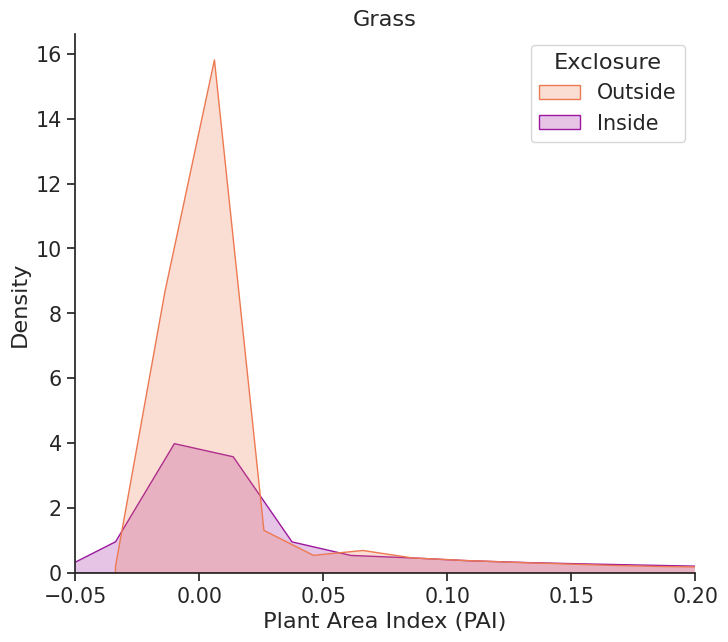

In [39]:
# Grass Pixels zoomed in
fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels.loc[df_pixels.VegType == 'grass'],
            x=f'PAI',
            hue='Exclosure',
            ax=ax, 
            palette='plasma_r',
            fill=True,
            hue_order=exclosure_hues)

ax.set_xlim(-0.05, 0.2)
ax.set_xlabel('Plant Area Index (PAI)')
ax.set_title(f'Grass')

fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_Grass_Xlimited_{projstr}.jpg', dpi=300)

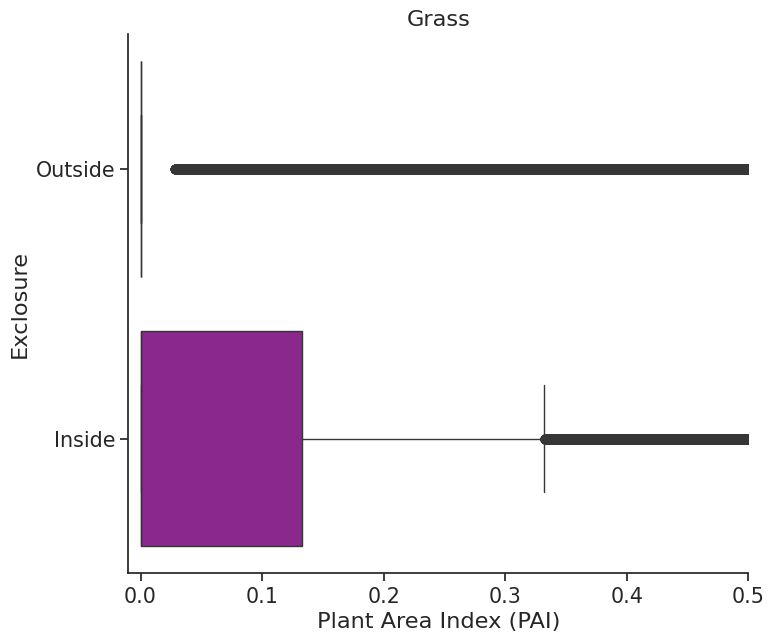

In [40]:
# Grass Pixels zoomed in
fig, ax = plt.subplots()

sns.boxplot(data=df_pixels.loc[df_pixels.VegType == 'grass'],
            x=f'PAI',
            y='Exclosure',
            hue='Exclosure',
            ax=ax, 
            palette='plasma_r',
            hue_order=exclosure_hues)

ax.set_xlim(-0.01, 0.5)
ax.set_xlabel('Plant Area Index (PAI)')
ax.set_title(f'Grass')

fig.savefig(f'{figdir}/Boxplot_PAIbyExclosure_Grass_Xlimited_{projstr}.jpg', dpi=300)

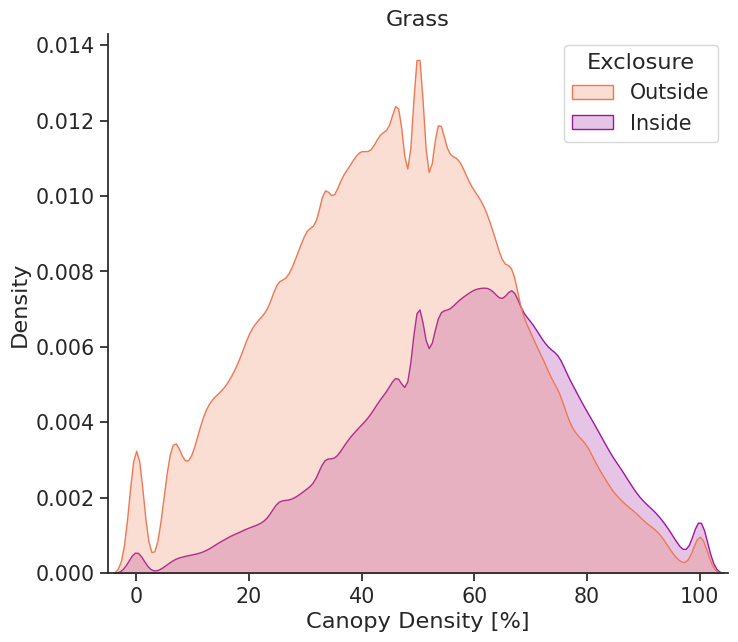

In [41]:
# Grass Pixels zoomed in
fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels.loc[df_pixels.VegType == 'grass'],
            x=f'CanopyDensityPercent',
            hue='Exclosure',
            ax=ax, 
            palette='plasma_r',
            fill=True,
            hue_order=exclosure_hues)

ax.set_xlim(-5, 105)
ax.set_xlabel('Canopy Density [%]')
ax.set_title(f'Grass')

fig.savefig(f'{figdir}/KDEplot_CanopyDensitybyExclosure_Grass_Xlimited_{projstr}.jpg', dpi=300)

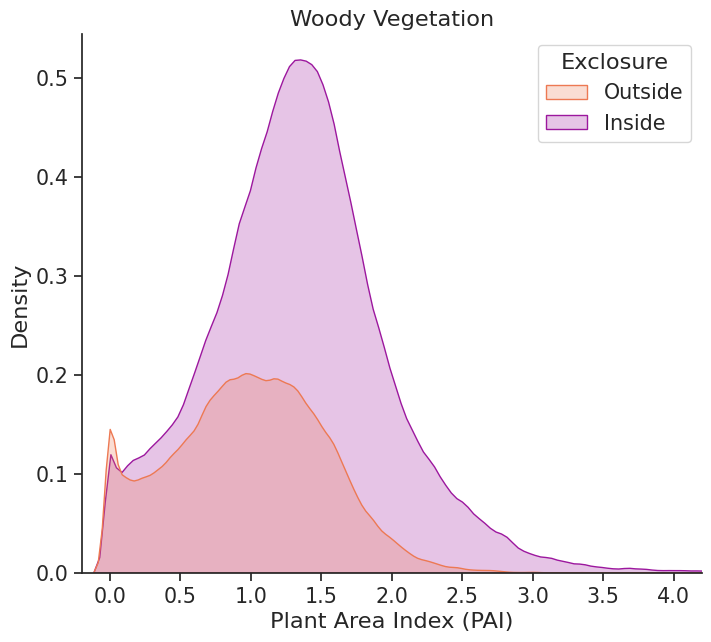

In [42]:
# Grass and woody plots
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots()

woodyidx = (df_pixels.Height > 1)

sns.kdeplot(data=df_pixels.loc[woodyidx],
            x=f'PAI',
            hue='Exclosure',
            ax=ax, 
            palette='plasma_r',
            fill=True,
            hue_order=exclosure_hues)

ax.set_xlim(-0.2, 4.2)
ax.set_xlabel('Plant Area Index (PAI)')
ax.set_title(f'Woody Vegetation')

fig.savefig(f'{figdir}/KDEplot_PAIbyExclosure_WoodyVeg_{projstr}.png', dpi=300)

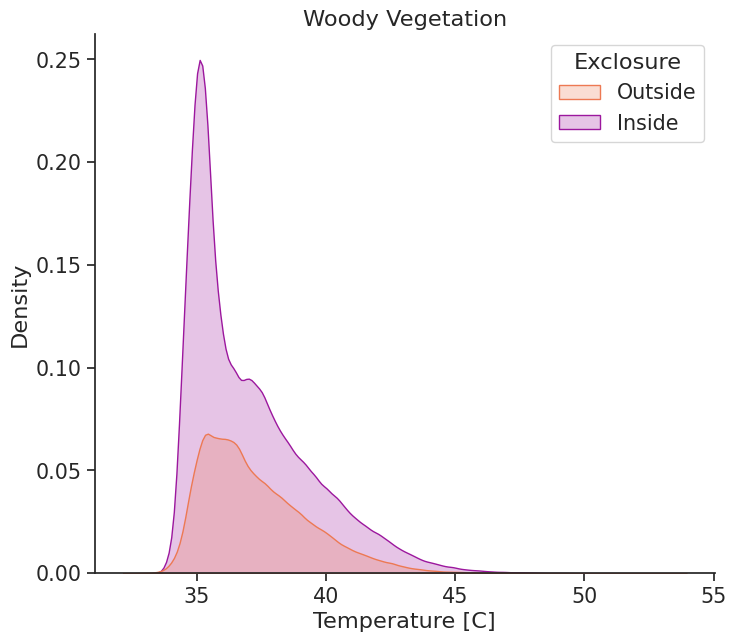

In [43]:
# Grass and woody plots
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots()

woodyidx = (df_pixels.Height > 1)

sns.kdeplot(data=df_pixels.loc[woodyidx],
            x=f'Temperature',
            hue='Exclosure',
            ax=ax, 
            palette='plasma_r',
            fill=True,
            hue_order=exclosure_hues)

# ax.set_xlim(-0.2, 4.2)
ax.set_xlabel('Temperature [C]')
ax.set_title(f'Woody Vegetation')

fig.savefig(f'{figdir}/KDEplot_TempbyExclosure_WoodyVeg_{projstr}.png', dpi=300)

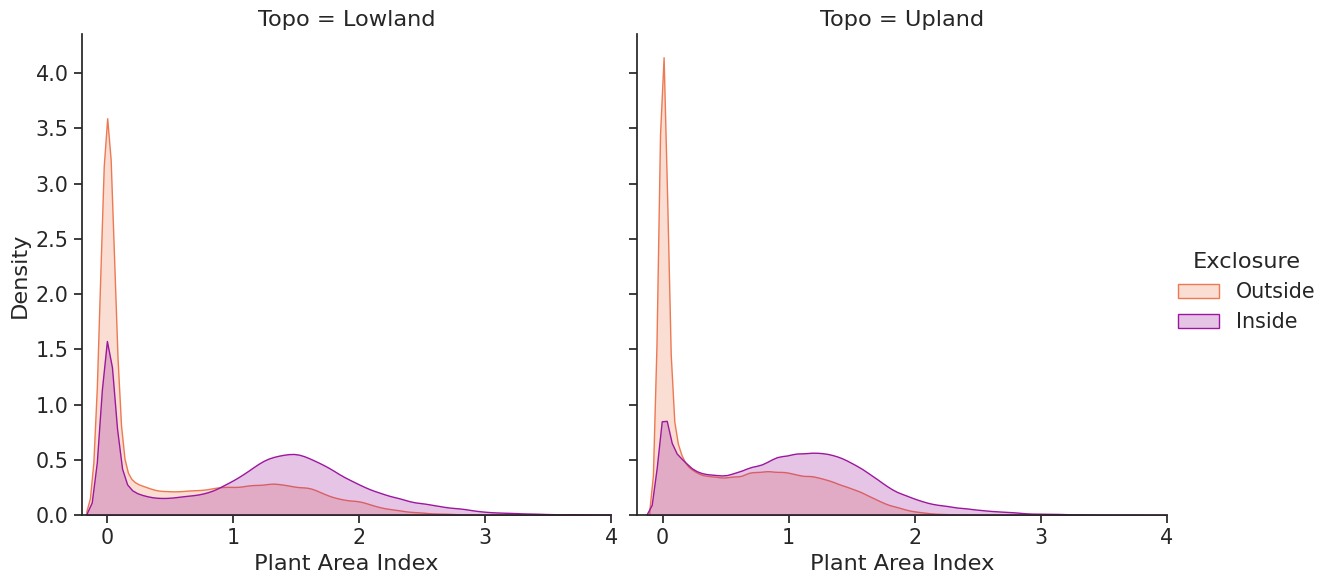

In [44]:
# Split by Lowland and Upland FacetGrid
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues, height=6,
                   col_order=['Lowland', 'Upland'])

FG.map_dataframe(sns.kdeplot, x='PAI', fill=True)

FG.set_xlabels('Plant Area Index')
    
FG.set_ylabels('Density')
    
FG.add_legend()
FG.set(xlim=(-0.2, 4))

FG.savefig(f'{figdir}/KDEplot_CanopyDensitybyExclosureandTopo_{projstr}.jpg', dpi=300)

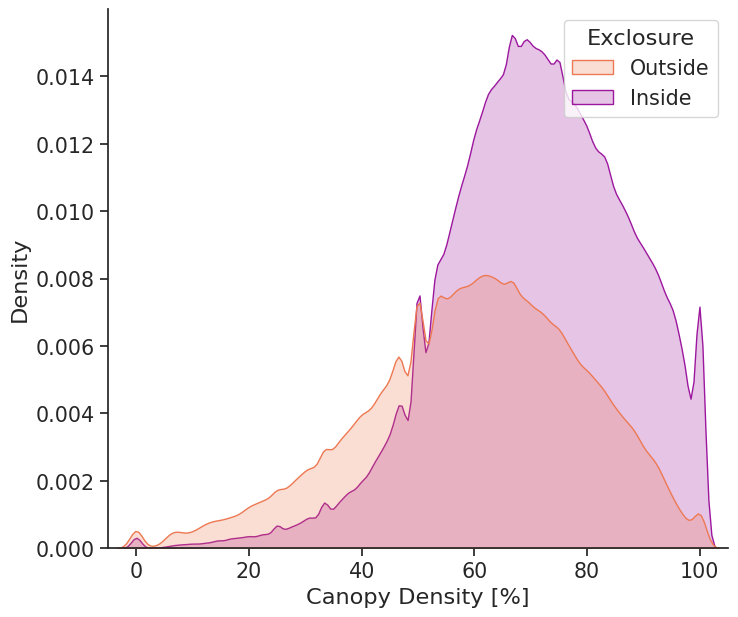

In [45]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels_0p1m, x='CanopyDensityPercent',
            hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlabel('Canopy Density [%]')
ax.set_xlim(-5, 105)
fig.savefig(f'{figdir}/KDEplot_CanopyDensitybyExclosure_{projstr}.jpg', dpi=300)

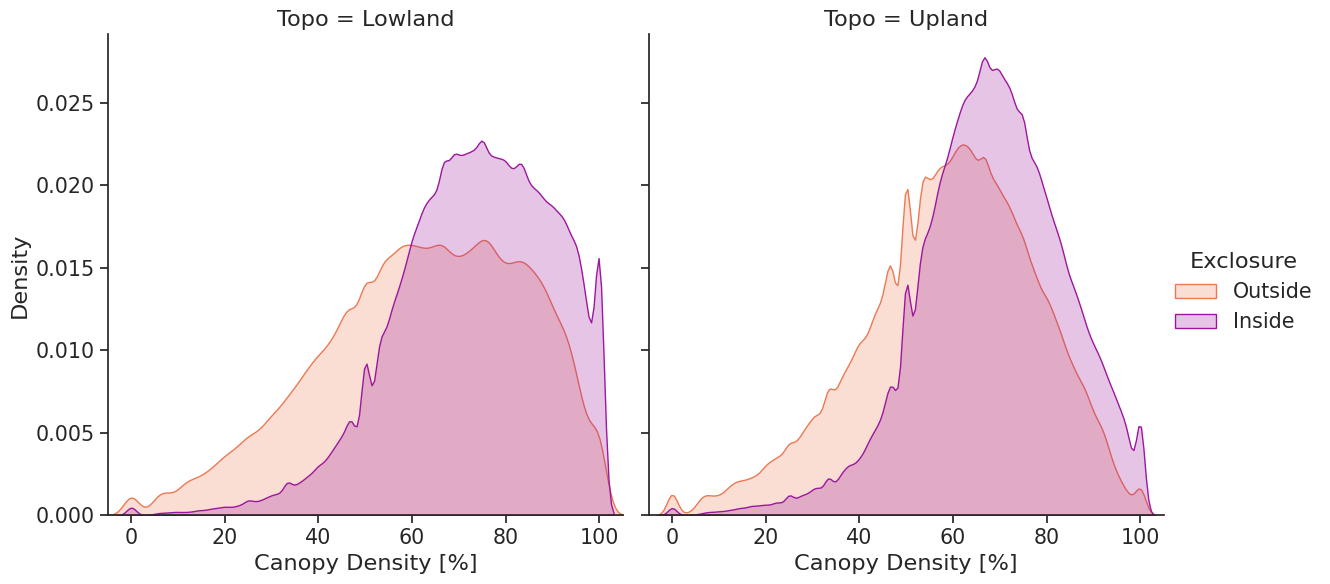

In [46]:
# Split by Lowland and Upland FacetGrid
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 12})

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels_0p1m, col='Topo', hue='Exclosure',
                   palette='plasma_r',
                   hue_order=exclosure_hues,
                   height=6, col_order=['Lowland', 'Upland'])

FG.map_dataframe(sns.kdeplot, x='CanopyDensityPercent', fill=True)

FG.set_xlabels('Canopy Density [%]')
    
FG.add_legend()
FG.set(xlim=(-5, 105))

FG.savefig(f'{figdir}/KDEplot_CanopyDensitybyExclosureandTopo_{projstr}.jpg',
           dpi=300)

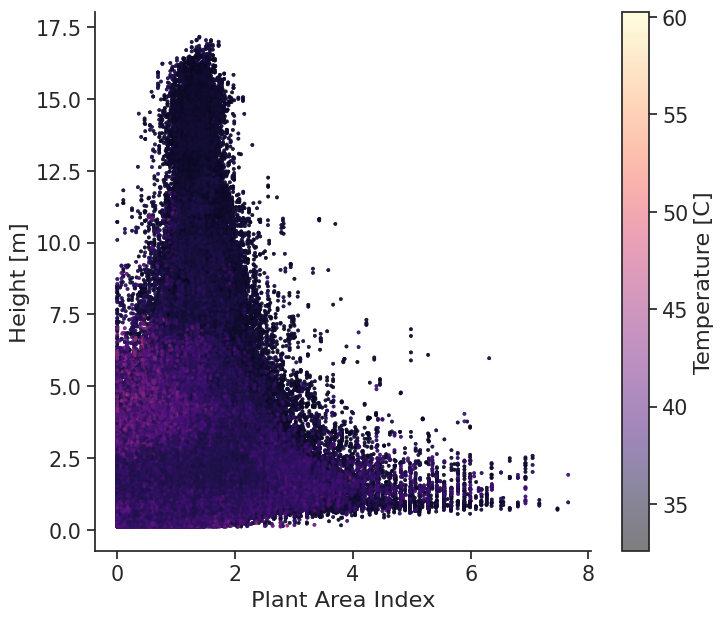

In [47]:
plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams.update({'font.size': 13})


fig, ax = plt.subplots()


a = ax.scatter(y=df_pixels_0p1m.Height,
               x=df_pixels_0p1m.PAI,
               c=df_pixels_0p1m.Temperature,
               alpha=0.5, cmap='magma', s=7, marker='o',
               edgecolors='none'
              )

fig.colorbar(a, label='Temperature [C]')

# ax.set_ylim(-0.2, 17.5)

ax.set_xlabel('Plant Area Index')
ax.set_ylabel('Height [m]')

fig.savefig(f'{figdir}/Scatterplot_PAIxHeight_TempColor_{projstr}.jpg',
           dpi=300)


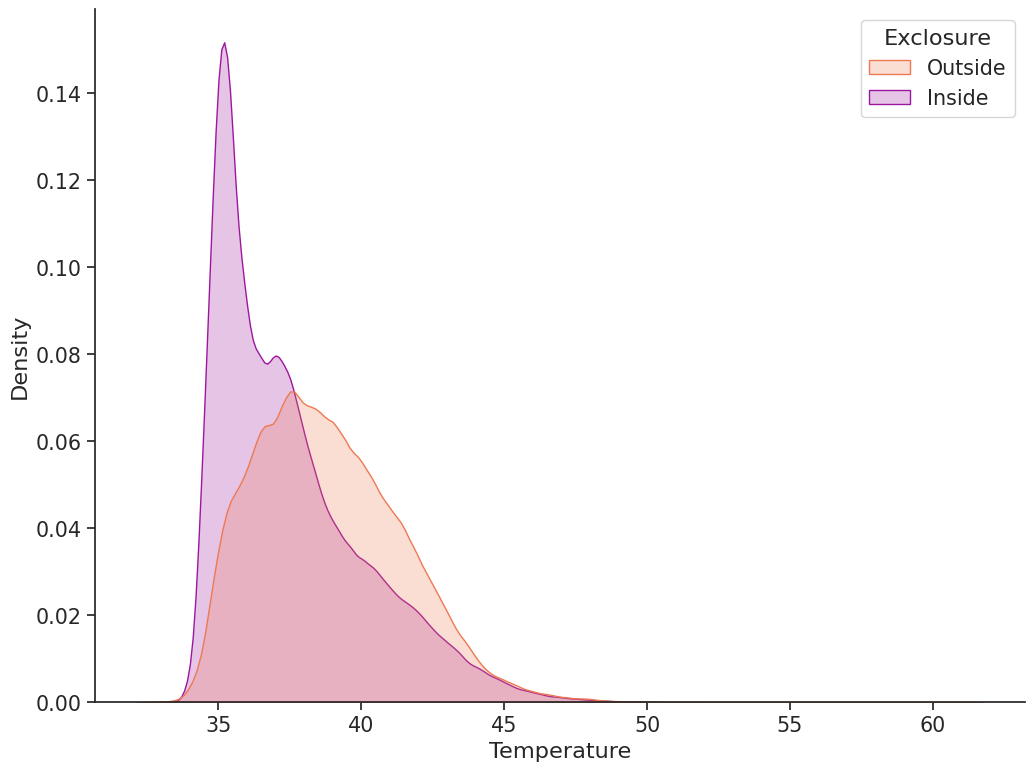

In [48]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 14})

fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels,
            x='Temperature',
            hue='Exclosure',
            ax=ax,
            palette='plasma_r',
            fill=True,
            hue_order=exclosure_hues)

fig.savefig(f'{figdir}/KDEplot_Exclosure_{projstr}.jpg', dpi=300)

#### NOTE: The Below GGST plots and stats need to be reworked
##### 12/1/22
Just to go with new vegtype column (before using a pixel based method)

In [49]:
# for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
#     fig, (ax1, ax2) = plt.subplots(1,2)
    
#     # Plot Upland and Lowland in seperate Columns
#     for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):

#         sns.displot(data=df_pixels.loc[df_pixels['Topo']==ul],
#                     x=f'Temperature_{ggst}',
#                     hue='Exclosure',
#                     ax=ax, 
#                     palette='plasma_r',
#                     hue_order=exclosure_hues,
#                     fill=True)

#         ax.set_title(f'{ul}')

#     fig.tight_layout()

#     fig.savefig(f'{figdir}/KDEPlot_Exclosure_{ggst}_UpLowSplit_{projstr}.jpg', dpi=300)

In [50]:
# for ggst in ['ground', 'grass', 'shrub', 'tree']:
    

#     # Use to dataframe to plot scatterplots of height v temp on a grid
#     FG = sns.FacetGrid(data=df_pixels, col='imgf', row='Exclosure', hue='Exclosure',
#                        palette='plasma_r', hue_order=exclosure_hues)

#     FG.map_dataframe(sns.histplot, x=f'Temperature_{ggst}', y='Height')
    
#     FG.add_legend()
#     FG.tight_layout()

#     FG.set_xlabels(f'Temperature of {ggst}')
#     FG.set_ylabels('Height [m]')

#     FG.savefig(f'{figdir}/ScatterPlot_TempvHeight_Exclosure_{ggst}_FacetGrid_{projstr}_{imgf}.jpg', dpi=300)

## Print Statistics and Plot

In [51]:
nLow = df_pixels.Topo.loc[df_pixels.Topo=='Lowland'].shape[0]
nUp = df_pixels.Topo.loc[df_pixels.Topo=='Upland'].shape[0]
print(f'Lowland: {nLow}, Upland: {nUp}')

nFull = df_pixels.Topo.loc[df_pixels.Exclosure=='Inside'].shape[0]
nOpen = df_pixels.Topo.loc[df_pixels.Exclosure=='Outside'].shape[0]
print(f'Open: {nOpen}, Full: {nFull}')

Lowland: 1981716, Upland: 2882916
Open: 2269572, Full: 2595060


In [52]:
df_stats = df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).describe()
df_stats.to_csv(f'{mast_path}/data/out/{projstr}_stats.csv')

In [53]:
df_pixels.groupby(['imgf', 'Topo', 'Exclosure']).mean()

TypeError: Could not convert ... to numeric

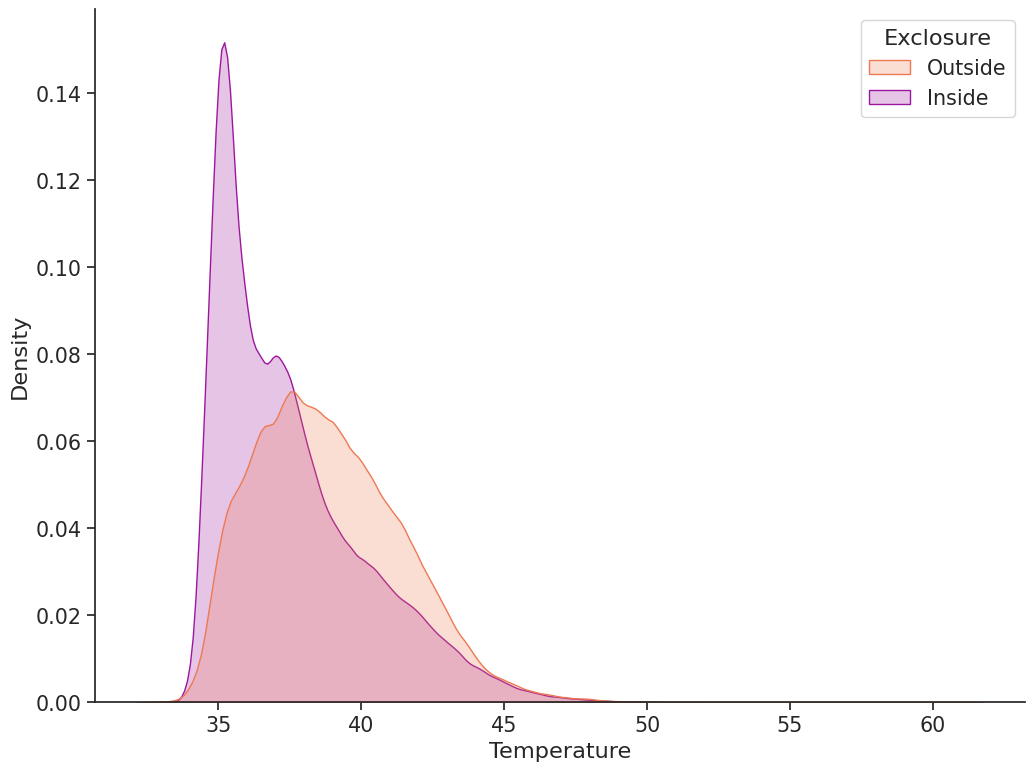

In [54]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)
fig.savefig(f'{figdir}/KDEplot_Exclosure_{projstr}.jpg', dpi=300)

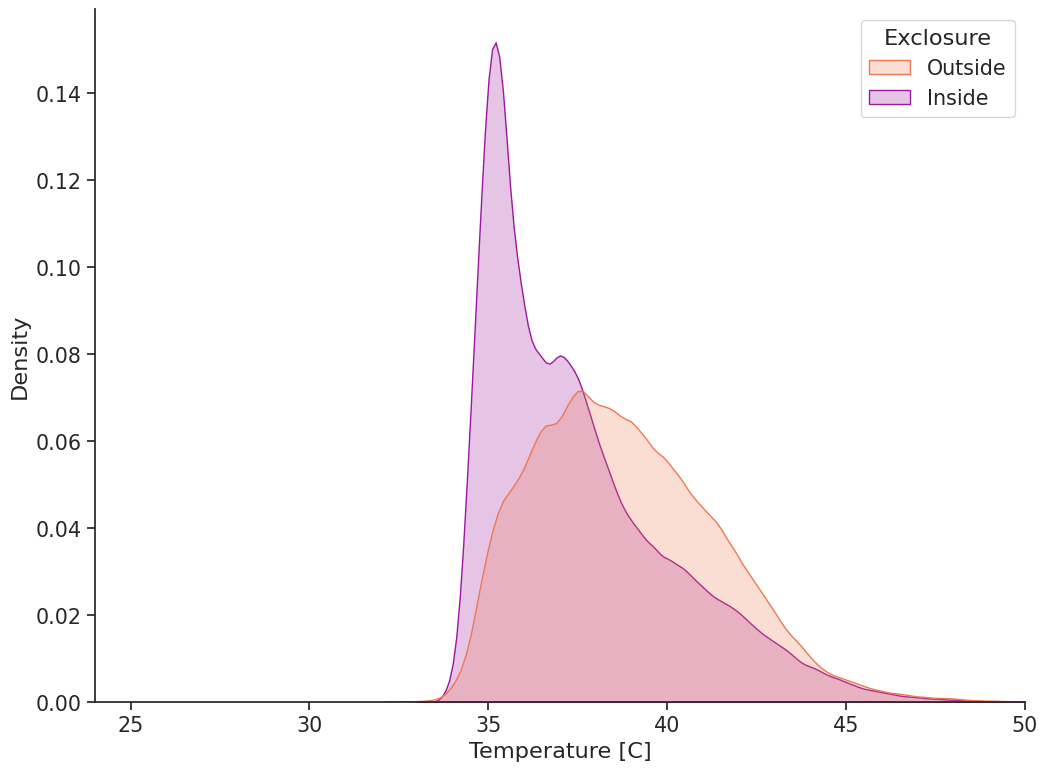

In [55]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots()
sns.kdeplot(data=df_pixels, x='Temperature', hue='Exclosure', ax=ax, palette='plasma_r',
            fill=True, hue_order=exclosure_hues)

ax.set_xlim(24, 50)
ax.set_xlabel('Temperature [C]')
# ax.set_title(f'{projstr} Temperature')

fig.savefig(f'{figdir}/KDEplot_Exclosure_Xlimited_{projstr}.jpg',
            dpi=300)

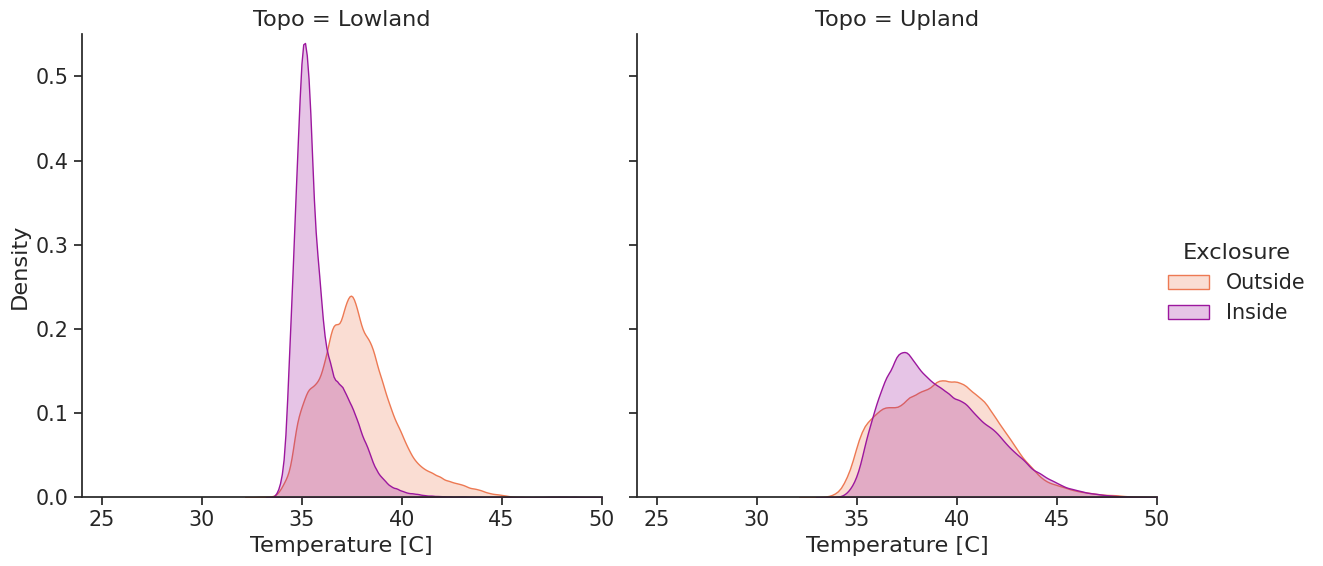

In [56]:
# Split by Lowland and Upland FacetGrid

# Use to dataframe to plot scatterplots of height v temp on a grid
FG = sns.FacetGrid(data=df_pixels, col='Topo', hue='Exclosure',
                   palette='plasma_r', hue_order=exclosure_hues,
                   height=6, col_order=['Lowland', 'Upland'])

FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)

FG.set_xlabels('Temperature [C]')
    
FG.set_ylabels('Density')
    
FG.add_legend()
FG.set(xlim=(24, 50), ylim=(0, 0.55))

FG.savefig(f'{figdir}/KDEplot_TempbyExclosure_UpLowSplit_Xlimited_{projstr}.png',
           dpi=300)

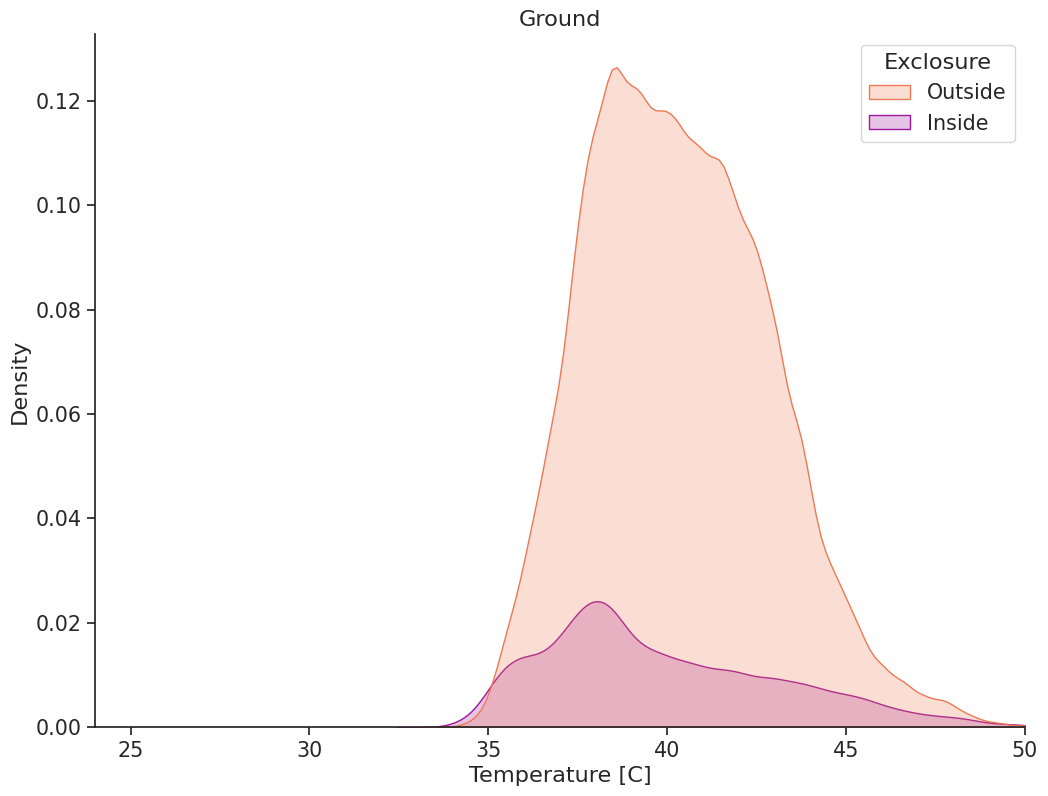

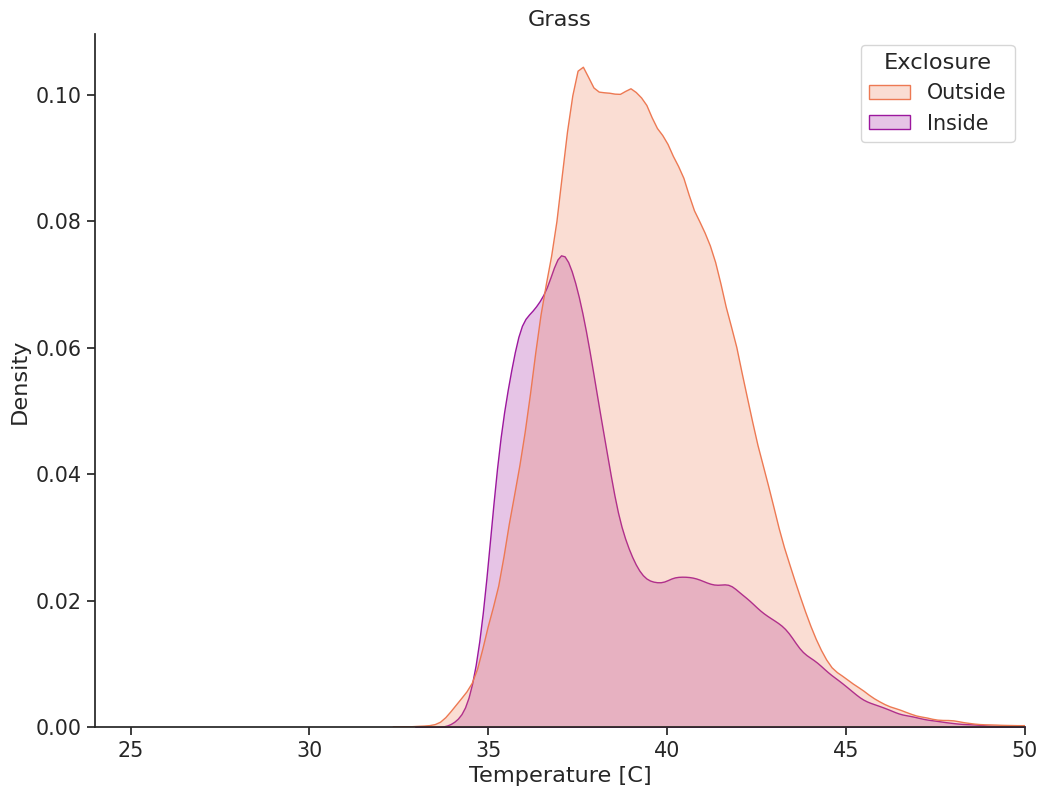

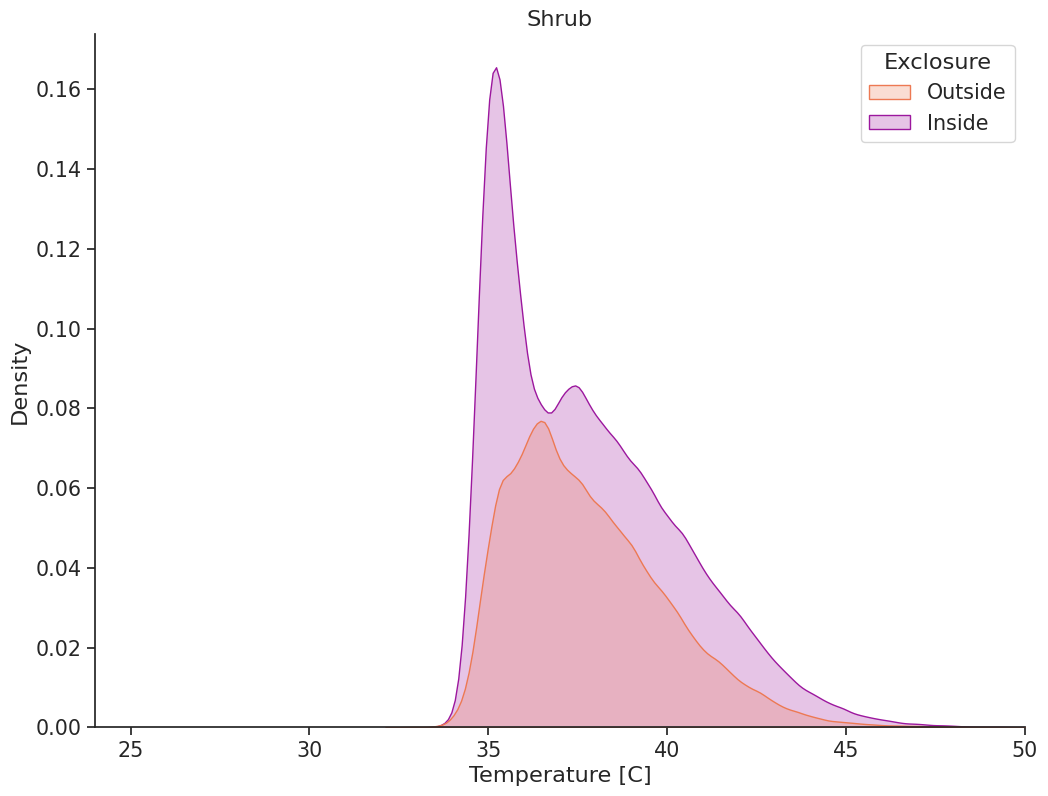

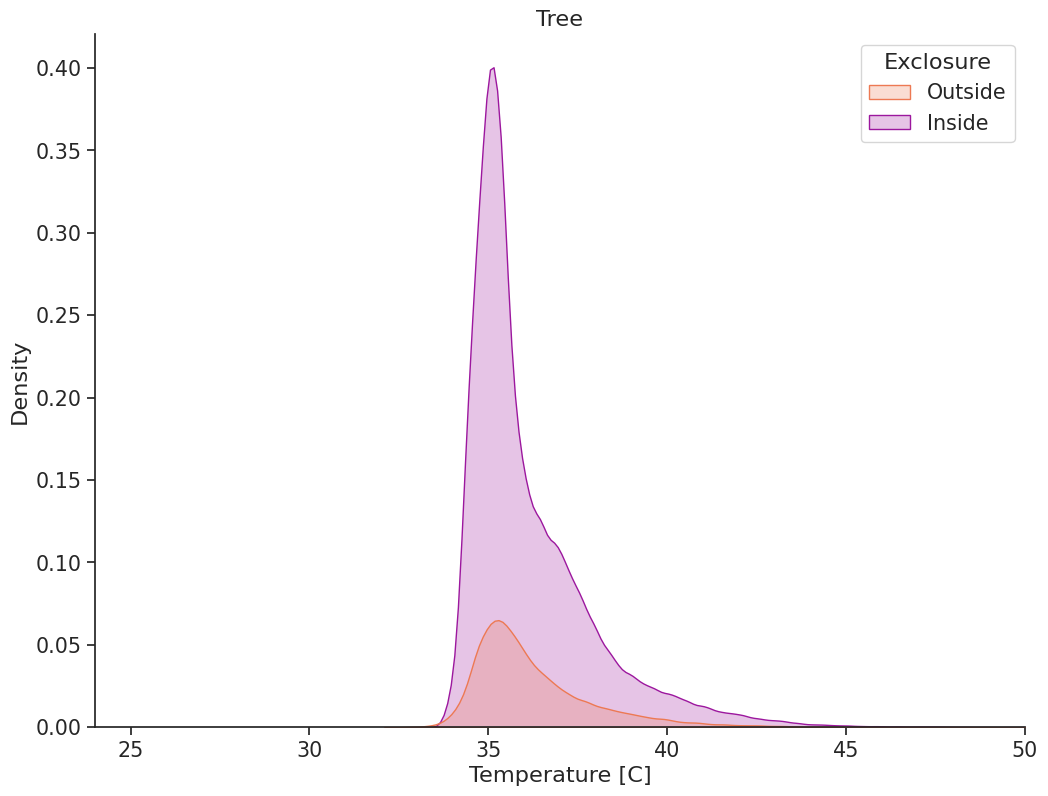

In [57]:
# Ground, grass, shrub, tree plots
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 18})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels.loc[df_pixels.VegType == ggst],
                x=f'Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                fill=True,
                hue_order=exclosure_hues)
    
    ax.set_xlim(24, 50)
    ax.set_xlabel('Temperature [C]')
    ax.set_title(f'{ggst.capitalize()}')
    
    fig.savefig(f'{figdir}/KDEplot_Exclosure_Xlimited_{ggst}_{projstr}.jpg', dpi=300)

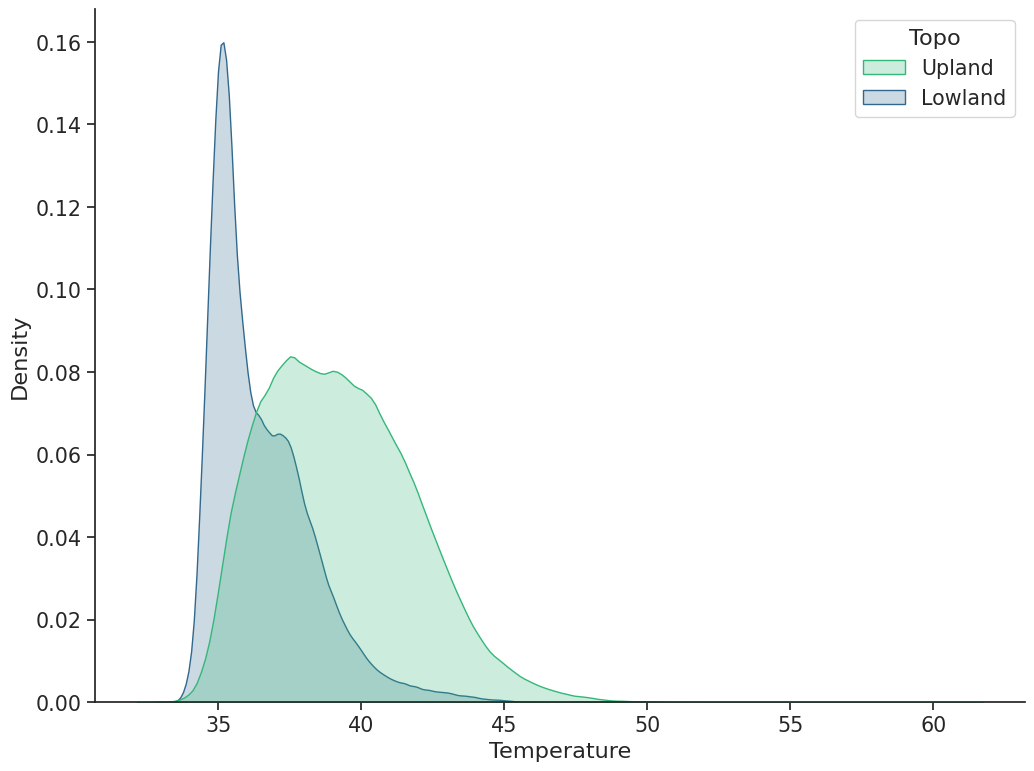

In [58]:
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 12})

fig, ax = plt.subplots()

sns.kdeplot(data=df_pixels,
            x='Temperature',
            hue='Topo',
            ax=ax,
            palette='viridis_r',
            fill=True,
            hue_order=topo_hues)

fig.savefig(f'{figdir}/KDEplot_Topo_{projstr}.jpg', dpi=300)

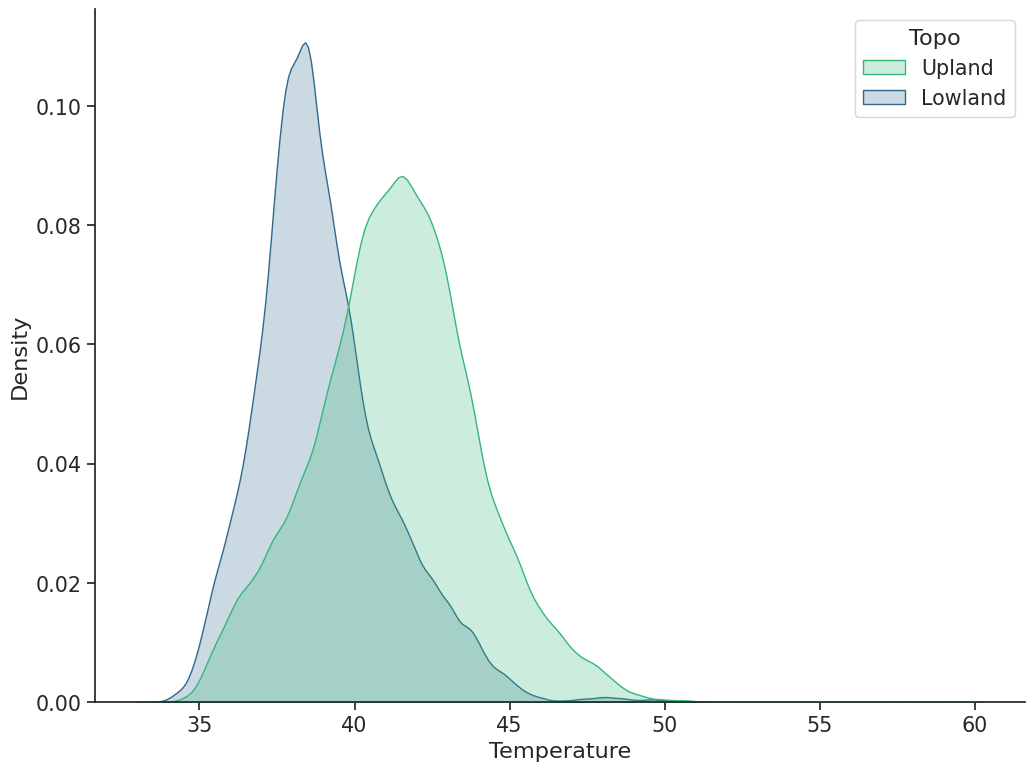

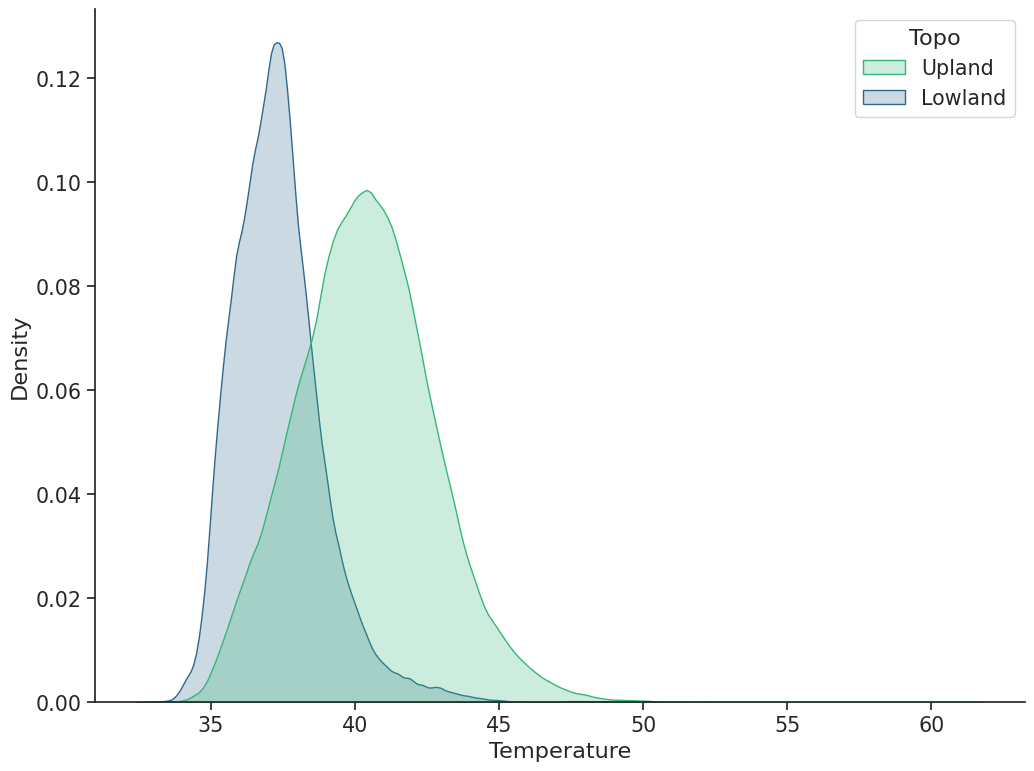

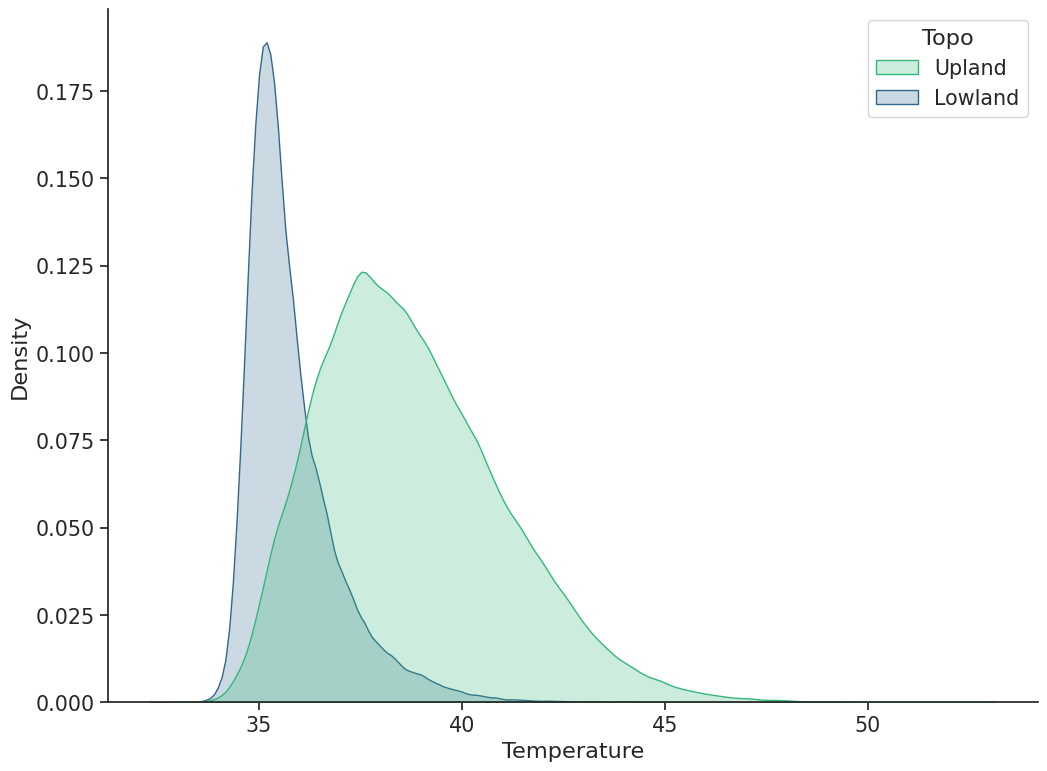

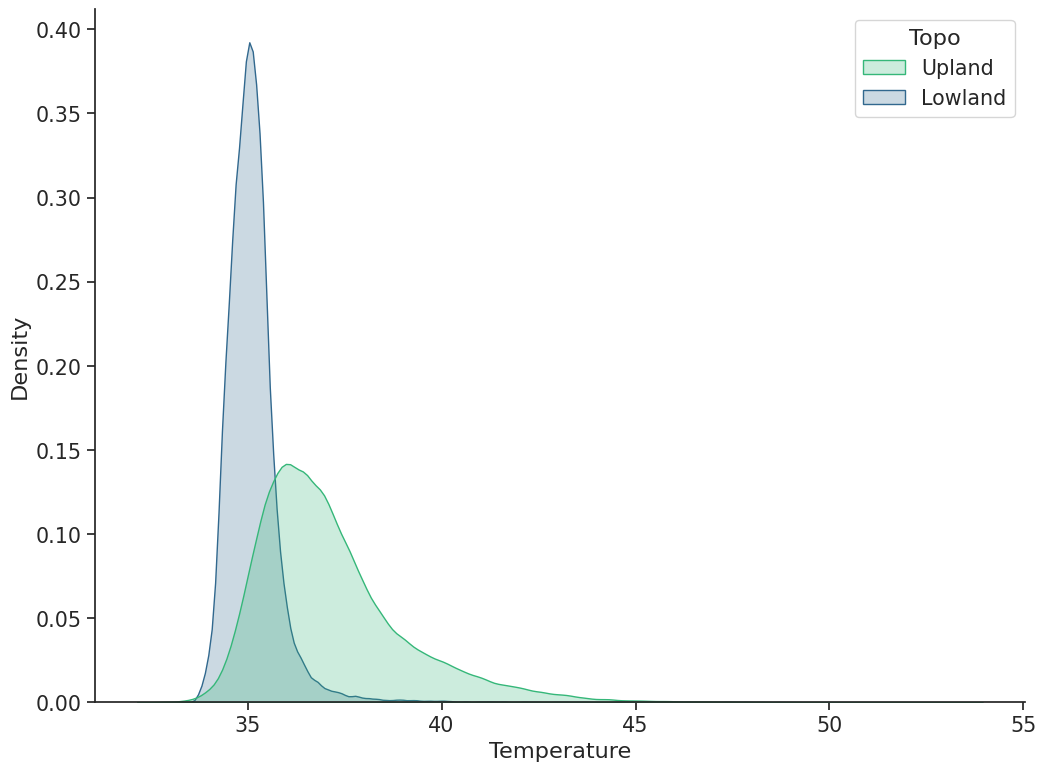

In [59]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    
    sns.kdeplot(data=df_pixels.loc[df_pixels.VegType==ggst], x=f'Temperature', hue='Topo', ax=ax, palette='viridis_r',
                fill=True, hue_order=topo_hues)
    
    fig.savefig(f'{figdir}/KDEplot_Topo_{ggst}_{projstr}.jpg', dpi=300)

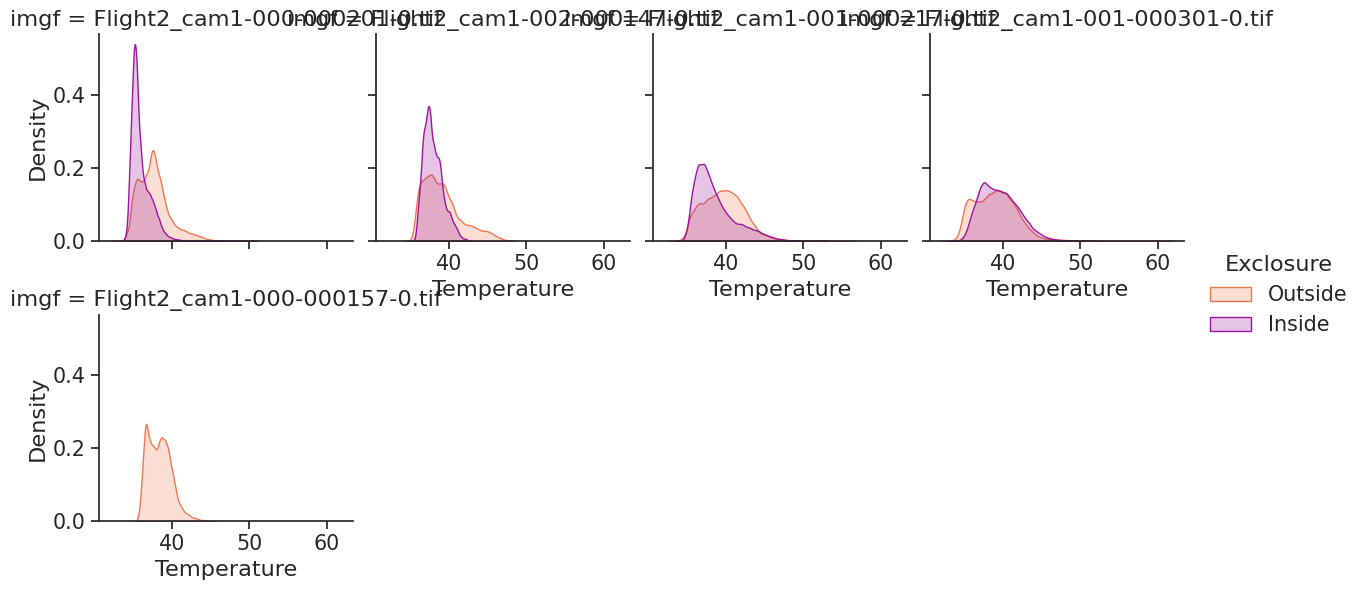

In [60]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Use to dataframe to plot KDE plots in a facetgrid
FG = sns.FacetGrid(data=df_pixels, 
                   col='imgf', hue='Exclosure', palette='plasma_r',
                   col_wrap=4, hue_order=exclosure_hues)

FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
FG.add_legend()
FG.tight_layout()

FG.set_xlabels(f'Temperature')
FG.set_ylabels(f'Density')

FG.savefig(f'{figdir}/KDEPlot_Exclosure_FacetGrid_{projstr}_byimg.jpg', dpi=300)

ValueError: Could not interpret value `Temperature_ground` for `x`. An entry with this name does not appear in `data`.

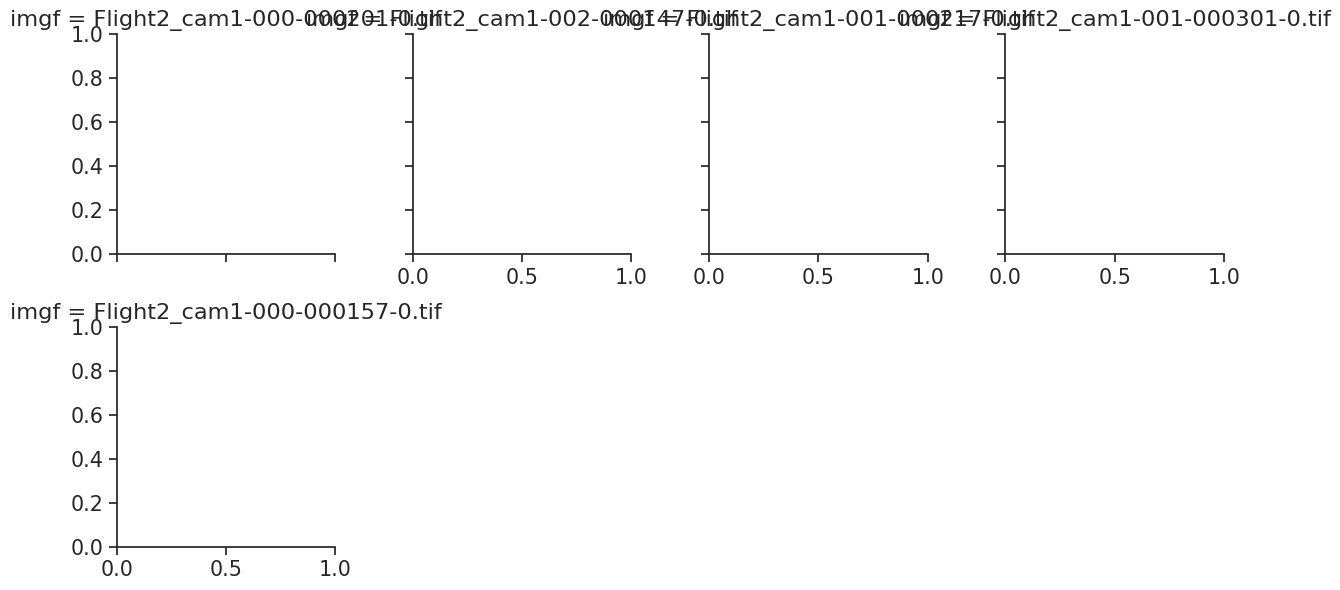

In [61]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels, col='imgf', hue='Exclosure', 
                       palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    
    FG.map_dataframe(sns.kdeplot, x=f'Temperature_{ggst}', fill=True)
    
    FG.add_legend()
    FG.tight_layout()
    
    FG.set_xlabels(f'Temperature of {ggst}')
    FG.set_ylabels('Density')

    FG.savefig(f'{figdir}/KDEPlot_Exclosure_{ggst}_FacetGrid_{projstr}_landscape.jpg', dpi=300)

In [62]:
# Use to dataframe to plot KDE plots in a facetgrid
# sns.kdeplot(pixel_dict['pixels_xr'][ID][idx].data.flatten()-273.15, ax=ax)
# FG = sns.FacetGrid(data=df_pixels, col='Exclosure',  row='imgf')
# FG = sns.FacetGrid(data=df_pixels, row='Topo', col='imgf',  hue='Exclosure', palette='plasma_r', hue_order=exclosure_hues)
# FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
# FG.add_legend()
# # ax.legend()

# FG.savefig(f'{figdir}/KDEPlot_Topo_FacetGrid_{projstr}_landscape.jpg', dpi=300)

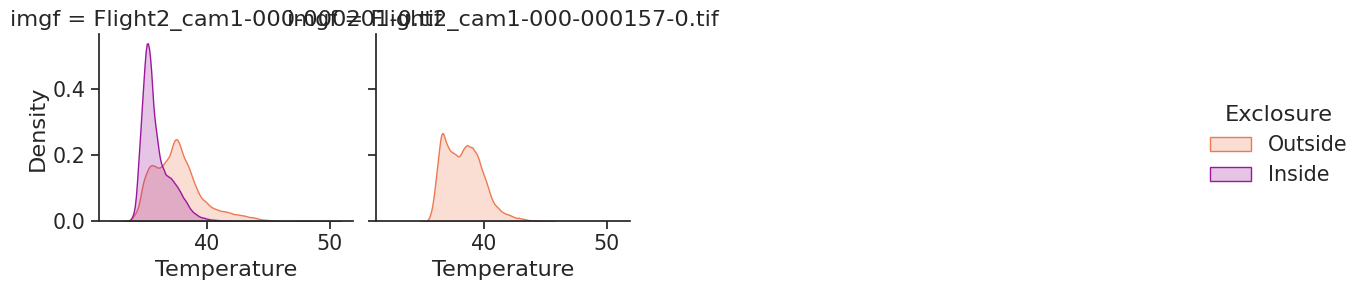

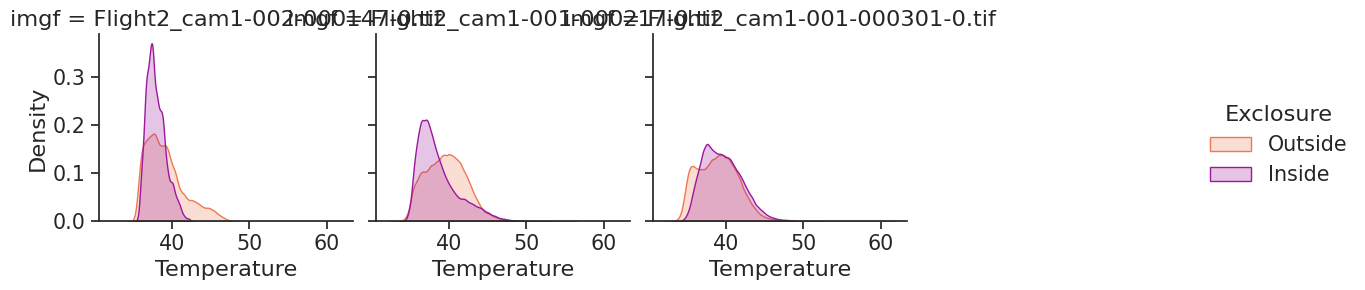

In [63]:
# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 10]
plt.rcParams.update({'font.size': 10})

# Plot Upland and Lowland in seperate Columns
for ul in ['Lowland', 'Upland']:
    
    # Use to dataframe to plot KDE plots in a facetgrid
    FG = sns.FacetGrid(data=df_pixels.loc[df_pixels['Topo']==ul], col='imgf',  hue='Exclosure', palette='plasma_r', col_wrap=4, hue_order=exclosure_hues)
    FG.map_dataframe(sns.kdeplot, x='Temperature', fill=True)
    FG.add_legend()
    
    FG.tight_layout()
    # ax.legend()

    FG.savefig(f'{figdir}/KDEPlot_{ul}_FacetGrid_{projstr}_landscape.jpg', dpi=300)

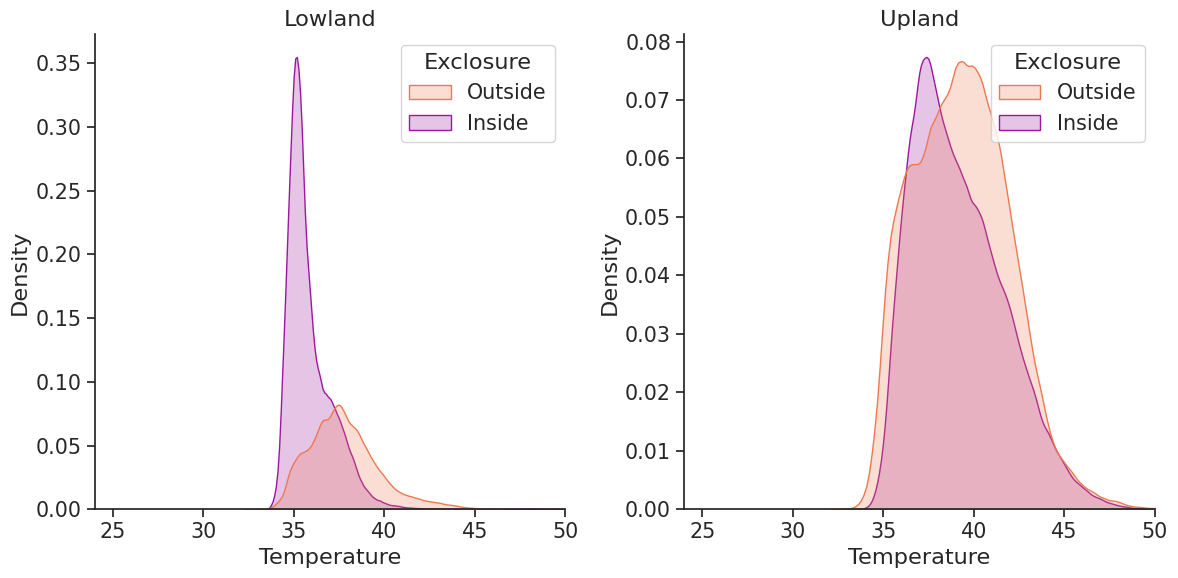

In [64]:
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams.update({'font.size': 14})
fig, (ax1, ax2) = plt.subplots(1,2)
# fig.savefig('{figdir}/KDEplot_Exclosure_Nkuhlu.jpg', dpi=300)

# Plot Upland and Lowland in seperate Columns
for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):
    
    sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                x='Temperature',
                hue='Exclosure',
                ax=ax, 
                palette='plasma_r',
                hue_order=exclosure_hues,
                fill=True)
                                   
    ax.set_title(f'{ul}')
    ax.set_xlim(24, 50)
    
fig.tight_layout()

fig.savefig(f'{figdir}/KDEPlot_Exclosure_UpLowSplit_Xlimited_{projstr}.jpg', dpi=300)

ValueError: Could not interpret value `Temperature_ground` for `x`. An entry with this name does not appear in `data`.

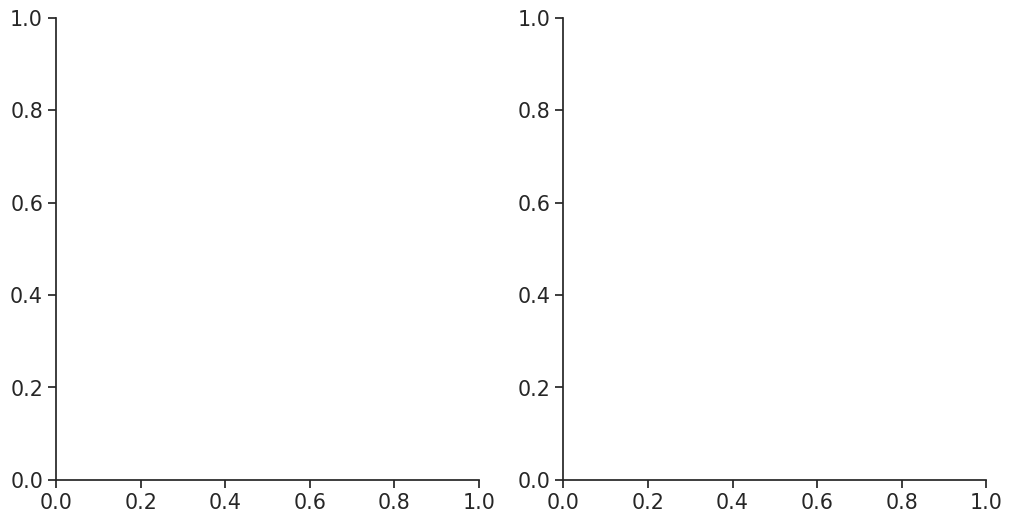

In [65]:
for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, (ax1, ax2) = plt.subplots(1,2)
    
    # Plot Upland and Lowland in seperate Columns
    for ul, ax in zip(['Lowland', 'Upland'], [ax1, ax2]):

        sns.kdeplot(data=df_pixels.loc[df_pixels['Topo']==ul],
                    x=f'Temperature_{ggst}',
                    hue='Exclosure',
                    ax=ax, 
                    palette='plasma_r',
                    hue_order=exclosure_hues,
                    fill=True)

        ax.set_title(f'{ul}')

    fig.tight_layout()

    fig.savefig(f'{figdir}/KDEPlot_Exclosure_{ggst}_UpLowSplit_{projstr}.jpg', dpi=300)

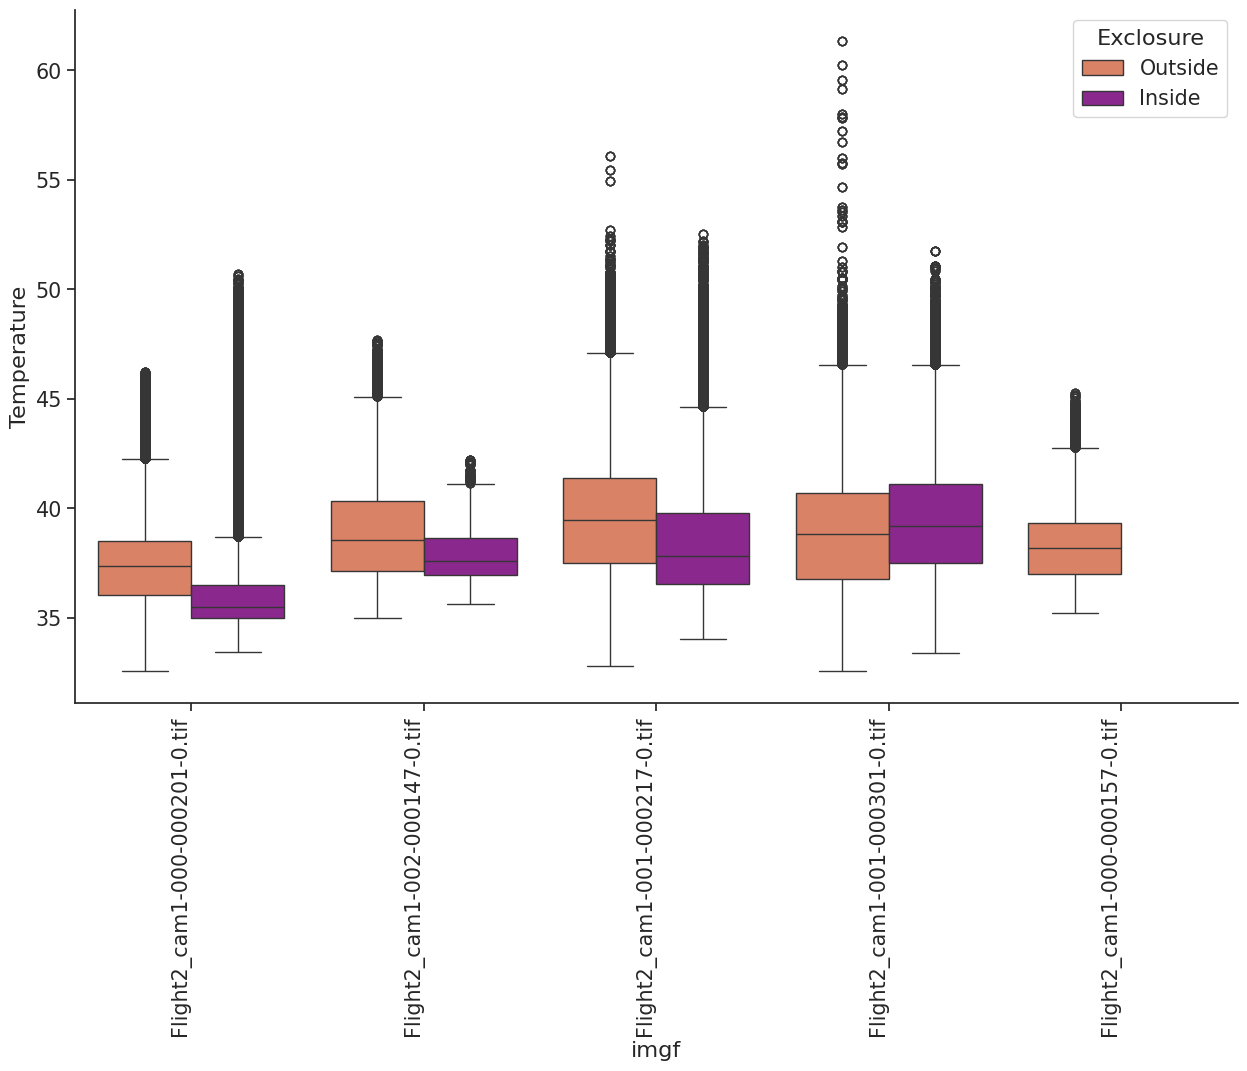

In [66]:
# Newly added 7/25 boxplot by image
plt.rcParams['figure.figsize'] = [15, 9]
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots()
sns.boxplot(data=df_pixels,
            x='imgf', y='Temperature', hue='Exclosure',
            ax=ax, palette='plasma_r', hue_order=exclosure_hues)
plt.xticks(rotation=90, ha='right')

fig.savefig(f'{figdir}/BoxplotByImage_Exclosure_{projstr}.jpg', dpi=300)

ValueError: Could not interpret value `Temperature_ground` for `y`. An entry with this name does not appear in `data`.

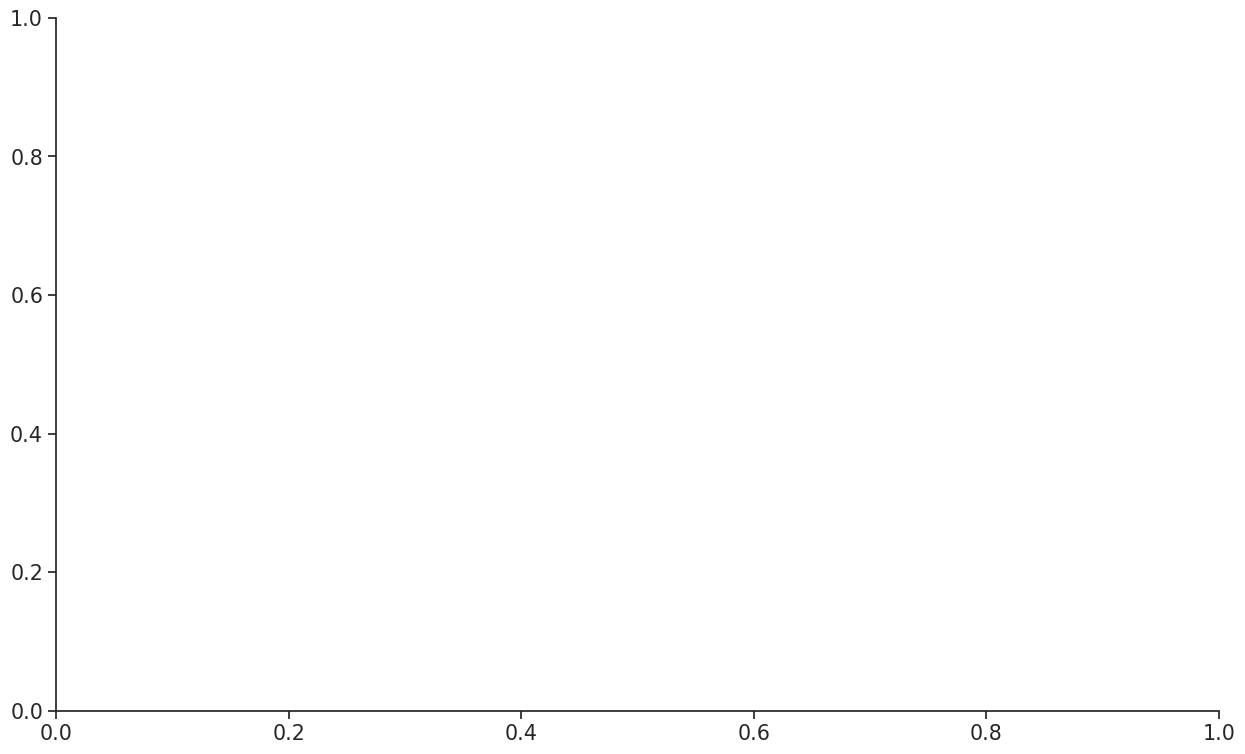

In [67]:
# Newly added 7/25 boxplot by image
plt.rcParams['figure.figsize'] = [15, 9]
plt.rcParams.update({'font.size': 13})

for ggst in ['ground', 'grass', 'shrub', 'tree']:
    
    fig, ax = plt.subplots()
    sns.boxplot(data=df_pixels,
                x='imgf', y=f'Temperature_{ggst}', hue='Exclosure',
                ax=ax, palette='plasma_r', hue_order=exclosure_hues)
    plt.xticks(rotation=90, ha='right')

    fig.savefig(f'{figdir}/BoxplotByImage_Exclosure_{ggst}_{projstr}.jpg', dpi=300)